# Setup FinRL

In [ ]:

!pip install wrds
!pip install swig
!pip install -q condacolab
import condacolab
condacolab.install()
!apt-get update -y -qq && apt-get install -y -qq cmake libopenmpi-dev python3-dev zlib1g-dev libgl1-mesa-glx swig
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 11.9 MB/s eta 0:00:00
⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:13
🔁 Restarting kernel...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package swig4.0.
(Reading database ... 126101 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ubuntu1_all.deb ...
Unpacking swig (4.0.2-1ubuntu1) ...
Setting up swig4.0 (4.0.2-1ubuntu1) ...
Setting

In [ ]:
!pip install pandas_market_calendars

# Read Train Data

In [28]:
import pandas as pd
df = pd.read_csv("train_with_sentiment.csv", index_col=0)


In [29]:
import os
import pandas as pd

from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from stable_baselines3.common.logger import configure
from finrl import config_tickers
from finrl.main import check_and_make_directories
from finrl.config import INDICATORS, TRAINED_MODEL_DIR, RESULTS_DIR

check_and_make_directories([TRAINED_MODEL_DIR])


In [30]:
train = df


# Define Stock Environment from FinRL

In [31]:
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

tech_indicators = ['macd', 'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30',
                   'close_30_sma', 'close_60_sma', 'vix', 'turbulence', 'sentiment_2w']

stock_dim = len(train['tic'].unique())
state_space = 1 + 2*stock_dim + stock_dim*len(tech_indicators)
action_space = stock_dim

env = StockTradingEnv(
    df=train,
    stock_dim=stock_dim,
    hmax=100,
    initial_amount=1_000_000,
    num_stock_shares=[0]*stock_dim,
    buy_cost_pct=[0.001]*stock_dim,
    sell_cost_pct=[0.001]*stock_dim,
    reward_scaling=1e-4,
    state_space=state_space,
    action_space=action_space,
    tech_indicator_list=tech_indicators,
    print_verbosity=50,
    turbulence_threshold=None,
    risk_indicator_col="turbulence"
)


# PPO Agent

In [ ]:

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_sizes=(64,64)):
        super().__init__()
        layers = []
        last = state_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        self.shared = nn.Sequential(*layers)
        self.mean = nn.Linear(last, action_dim)
        self.log_std = nn.Parameter(torch.zeros(action_dim))
        self.value = nn.Linear(last, 1)

    def forward(self, x):
        x = self.shared(x)
        return self.mean(x), torch.exp(self.log_std), self.value(x)


class PPOAgent:
    def __init__(
        self,
        env,
        gamma = 0.99,
        lam = 0.95,
        clip_eps = 0.2,
        lr = 3e-4,
        K_epochs = 10,
        batch_size = 64,
        update_timestep = 2048,
        hidden_sizes = (64,64),
        log_interval = 100,
        device = None
    ):
        self.env = env
        self.gamma = gamma
        self.lam = lam
        self.clip_eps = clip_eps
        self.K_epochs = K_epochs
        self.batch_size = batch_size
        self.update_timestep = update_timestep
        self.log_interval = log_interval
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        obs_shape = env.observation_space.shape
        act_shape = env.action_space.shape
        self.state_dim = obs_shape[0]
        self.action_dim = act_shape[0]
        self.act_low = float(env.action_space.low[0])
        self.act_high = float(env.action_space.high[0])

        self.model = ActorCritic(self.state_dim, self.action_dim, hidden_sizes).to(self.device)
        self.old_model = ActorCritic(self.state_dim, self.action_dim, hidden_sizes).to(self.device)
        self.old_model.load_state_dict(self.model.state_dict())
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

        self.reset_buffer()
        self.timestep = 0

        self.episodes = []
        self.end_values = []
        self.end_rewards = []
        self.end_trades = []
        self.end_sharpes = []

    def reset_buffer(self):
        self.states = []
        self.actions = []
        self.logprobs = []
        self.rewards = []
        self.is_terminals = []
        self.values = []

    def select_action(self, state):
        state_t = torch.FloatTensor(state).to(self.device)
        mean, std, val = self.old_model(state_t)
        dist = torch.distributions.Normal(mean, std)
        action = dist.sample()
        action_clamped = torch.clamp(action, self.act_low, self.act_high)
        logp = dist.log_prob(action).sum()

        self.states.append(state_t)
        self.actions.append(action)
        self.logprobs.append(logp)
        self.values.append(val.squeeze())

        return action_clamped.cpu().numpy()

    def compute_gae(self, next_value):
        vals = self.values + [next_value]
        gae = 0.0
        returns = []
        for i in reversed(range(len(self.rewards))):
            mask = 1.0 - float(self.is_terminals[i])
            delta = self.rewards[i] + self.gamma * vals[i+1] * mask - vals[i]
            gae = delta + self.gamma * self.lam * mask * gae
            returns.insert(0, gae + vals[i])
        return returns

    def update(self):
        S = torch.stack(self.states).to(self.device)
        A = torch.stack(self.actions).to(self.device)
        L = torch.stack(self.logprobs).to(self.device).detach()
        R = torch.FloatTensor(self.returns).to(self.device)
        V = torch.FloatTensor(self.values).to(self.device)

        adv = (R - V)
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        N = S.size(0)
        for _ in range(self.K_epochs):
            idx = np.arange(N)
            np.random.shuffle(idx)
            for start in range(0, N, self.batch_size):
                b = idx[start:start+self.batch_size]
                m, s, v = self.model(S[b])
                dist = torch.distributions.Normal(m, s)
                logp = dist.log_prob(A[b]).sum(dim=1)
                ratio = (logp - L[b]).exp()

                surr1 = ratio * adv[b]
                surr2 = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * adv[b]
                policy_loss = -torch.min(surr1, surr2).mean()
                value_loss = nn.MSELoss()(v.squeeze(), R[b])
                loss = policy_loss + 0.5 * value_loss

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

        self.old_model.load_state_dict(self.model.state_dict())
        self.reset_buffer()

    def learn(self, total_timesteps, verbose=False):
        reset_out = self.env.reset()
        state = reset_out[0] if isinstance(reset_out, tuple) else reset_out
        state = np.asarray(state)  

        while self.timestep < total_timesteps:
            action = self.select_action(state)
            step_out = self.env.step(action)

            if len(step_out) == 5:
                obs, reward, term, trunc, _ = step_out
                done = bool(term or trunc)
            else:
                obs, reward, done, _ = step_out

            state = np.asarray(obs)
            reward = float(reward)
            terminal = bool(done)

            self.rewards.append(reward)
            self.is_terminals.append(terminal)
            self.timestep += 1

            if self.timestep % self.log_interval == 0:
                env = self.env
                st = env.state
                cash = st[0]
                stock_val = sum(
                    p * h for p,h in zip(
                        st[1:1+env.stock_dim],
                        st[1+env.stock_dim:1+2*env.stock_dim]
                    )
                )
                total_asset = cash + stock_val
                num_pos = sum(1 for h in st[1+env.stock_dim:1+2*env.stock_dim] if h>0)
                trades = env.trades
                print(f"[Step {self.timestep:5d}] Day {env.day:4d} | "
                      f"Portf=${total_asset:,.2f} | Cash=${cash:,.2f} | "
                      f"Pos={num_pos} | Trades={trades}")

            if self.timestep % self.update_timestep == 0:
                with torch.no_grad():
                    next_val = self.model(torch.FloatTensor(state).to(self.device))[2].item()
                self.returns = self.compute_gae(next_val)
                self.update()

            if terminal:
                env = self.env
                assets = np.array(env.asset_memory)
                final = assets[-1]
                self.episodes.append(env.episode)
                self.end_values.append(final)
                self.end_rewards.append(final - assets[0])
                self.end_trades.append(env.trades)
                dr = assets[1:] / assets[:-1] - 1
                sr = (dr.mean()/(dr.std()+1e-8)) * np.sqrt(252)
                self.end_sharpes.append(sr)

                reset_out = env.reset()
                state = reset_out[0] if isinstance(reset_out, tuple) else reset_out
                state = np.asarray(state)

            if verbose and self.timestep % (total_timesteps // 10) == 0:
                print(f"Progress: {100*self.timestep/total_timesteps:.1f}%")

        print("Training complete.")
        print(f"Logged {len(self.episodes)} episodes.")

    def predict(self, state):
        state_arr = np.asarray(state)
        with torch.no_grad():
            mean, _, _ = self.model(torch.FloatTensor(state_arr).to(self.device))
        action = torch.clamp(mean, self.act_low, self.act_high)
        return action.cpu().numpy()

    def save(self, path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        torch.save(self.model.state_dict(), path)

    def load(self, path):
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.old_model.load_state_dict(self.model.state_dict())


# Train Code for PPO

In [ ]:
from stable_baselines3.common.vec_env import DummyVecEnv
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

raw_env = StockTradingEnv(
    df = train,                     
    stock_dim = stock_dim,
    hmax = 100,                        
    initial_amount = 1_000_000,        
    num_stock_shares = [0]*stock_dim,  
    buy_cost_pct = [0.001]*stock_dim,  
    sell_cost_pct = [0.001]*stock_dim, 
    reward_scaling = 1e-4,            
    state_space = state_space,
    action_space = action_space,
    tech_indicator_list = tech_indicators,
    print_verbosity = 50,              
    turbulence_threshold = None,       
    risk_indicator_col = "turbulence"
)

agent = PPOAgent(
    env = raw_env,
    gamma = 0.99,
    lam = 0.95,
    clip_eps = 0.2,
    lr = 3e-4,
    K_epochs = 10,
    batch_size = 64,
    update_timestep = 2048,
    log_interval = 100,    
)

agent.learn(total_timesteps = 25000, verbose = True)


agent.save("./models/ppo_from_scratch.pth")


[Step   100] Day  100 | Portf=$1,074,650.24 | Cash=$15.23 | Pos=11 | Trades=1415
[Step   200] Day  200 | Portf=$1,096,470.72 | Cash=$8.11 | Pos=12 | Trades=2693
[Step   300] Day  300 | Portf=$1,212,294.08 | Cash=$9.82 | Pos=11 | Trades=3988
[Step   400] Day  400 | Portf=$1,260,231.30 | Cash=$6.95 | Pos=11 | Trades=5302
[Step   500] Day  500 | Portf=$1,333,911.43 | Cash=$0.31 | Pos=11 | Trades=6607
[Step   600] Day  600 | Portf=$1,381,264.53 | Cash=$0.31 | Pos=11 | Trades=7899
[Step   700] Day  700 | Portf=$1,532,676.18 | Cash=$33.88 | Pos=11 | Trades=9193
[Step   800] Day   46 | Portf=$1,014,869.70 | Cash=$15.90 | Pos=12 | Trades=699
[Step   900] Day  146 | Portf=$1,114,941.07 | Cash=$2.63 | Pos=12 | Trades=2031
[Step  1000] Day  246 | Portf=$1,113,760.88 | Cash=$11.85 | Pos=11 | Trades=3363
[Step  1100] Day  346 | Portf=$1,199,101.59 | Cash=$1.42 | Pos=11 | Trades=4650
[Step  1200] Day  446 | Portf=$1,289,119.48 | Cash=$6.67 | Pos=11 | Trades=5960
[Step  1300] Day  546 | Portf=$1,367,

# Import Test Data

In [33]:
test_df = pd.read_csv("trade_with_sentiment.csv", index_col=0)

Test: 2019-01-02 → 2019-06-27 | Final=$1,110,525.63 | Return=11.05% | Sharpe=2.09


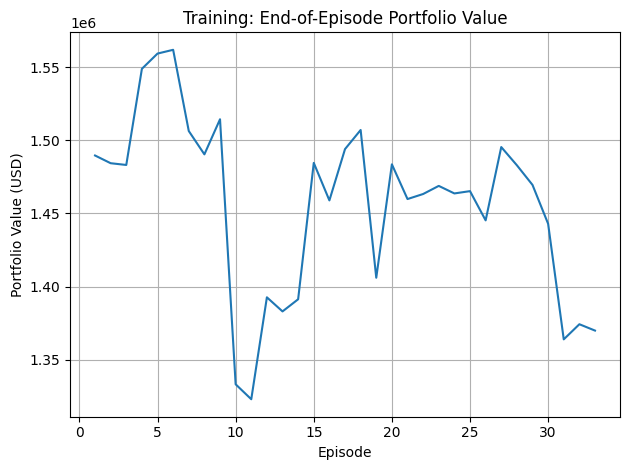

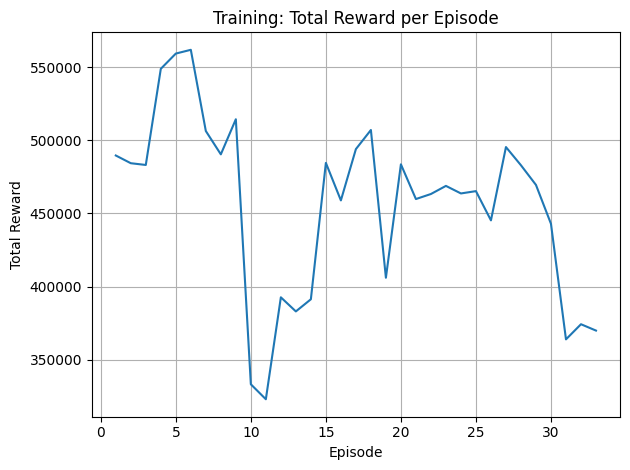

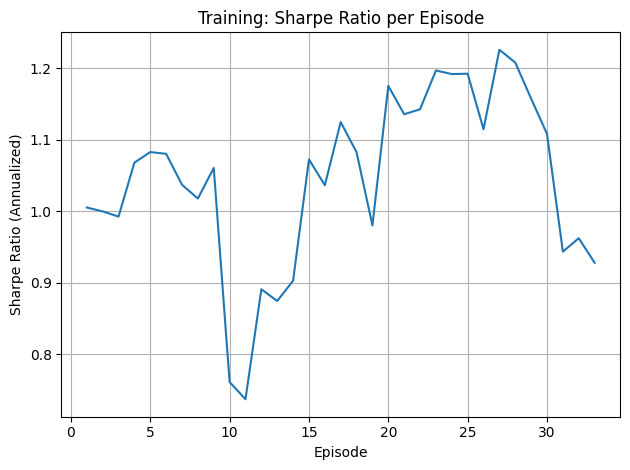

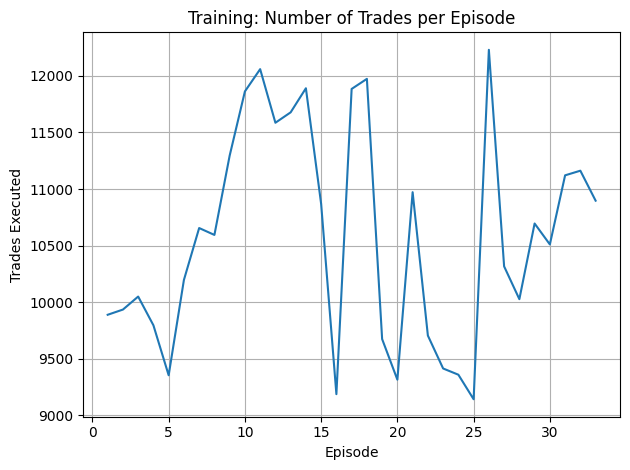

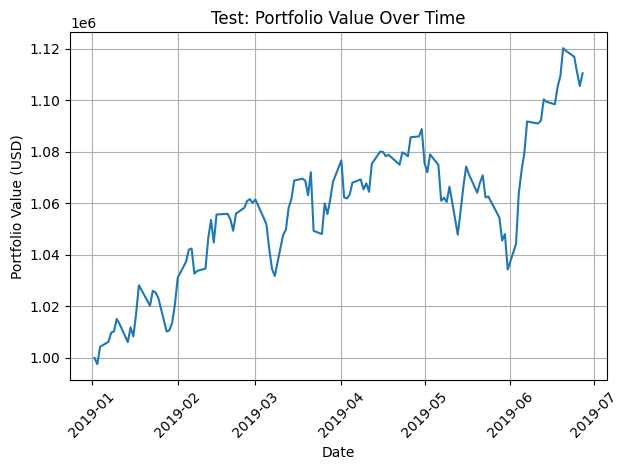

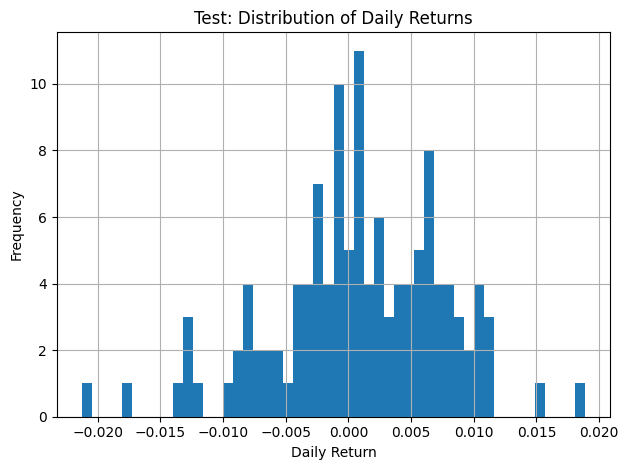

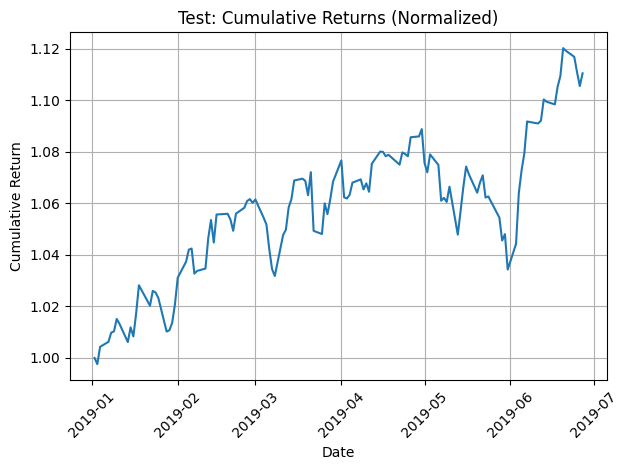

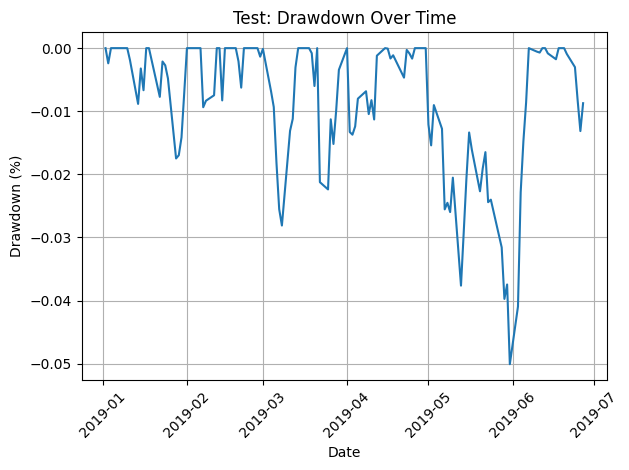

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

test_env = StockTradingEnv(
    df=test_df,                     
    stock_dim=stock_dim,
    hmax=100,
    initial_amount=1_000_000,
    num_stock_shares=[0]*stock_dim,
    buy_cost_pct=[0.001]*stock_dim,
    sell_cost_pct=[0.001]*stock_dim,
    reward_scaling=1e-4,
    state_space=state_space,
    action_space=action_space,
    tech_indicator_list=tech_indicators,
    print_verbosity=100,
    turbulence_threshold=None,
    risk_indicator_col="turbulence"
)

agent.load("./models/ppo_from_scratch.pth")

out = test_env.reset()
state = out[0] if isinstance(out, tuple) else out

done = False
while not done:
    action = agent.predict(state)
    step = test_env.step(action)
    if len(step) == 5:
        obs, reward, term, trunc, _ = step
        done = bool(term or trunc)
    else:
        obs, reward, done, _ = step
    state = obs if not isinstance(obs, tuple) else obs[0]

test_dates = pd.to_datetime(test_env.date_memory)
test_assets = np.array(test_env.asset_memory)
test_actions = test_env.save_action_memory()  

daily_rets = test_assets[1:] / test_assets[:-1] - 1
total_return = test_assets[-1] / test_assets[0] - 1
sharpe_ratio = (daily_rets.mean() / (daily_rets.std()+1e-8)) * np.sqrt(252)
print(f"Test: {test_dates[0].date()} → {test_dates[-1].date()} | "
      f"Final=${test_assets[-1]:,.2f} | Return={total_return*100:.2f}% | Sharpe={sharpe_ratio:.2f}")


episodes = agent.episodes
end_values = agent.end_values
end_rewards = agent.end_rewards
end_trades = agent.end_trades
end_sharpes = agent.end_sharpes

plt.figure()
plt.plot(episodes, end_values)
plt.title("Training: End-of-Episode Portfolio Value")
plt.xlabel("Episode"); plt.ylabel("Portfolio Value (USD)")
plt.grid(True); plt.tight_layout()
plt.show()

plt.figure()
plt.plot(episodes, end_rewards)
plt.title("Training: Total Reward per Episode")
plt.xlabel("Episode"); plt.ylabel("Total Reward")
plt.grid(True); plt.tight_layout()
plt.show()

plt.figure()
plt.plot(episodes, end_sharpes)
plt.title("Training: Sharpe Ratio per Episode")
plt.xlabel("Episode"); plt.ylabel("Sharpe Ratio (Annualized)")
plt.grid(True); plt.tight_layout()
plt.show()

plt.figure()
plt.plot(episodes, end_trades)
plt.title("Training: Number of Trades per Episode")
plt.xlabel("Episode"); plt.ylabel("Trades Executed")
plt.grid(True); plt.tight_layout()
plt.show()


plt.figure()
plt.plot(test_dates, test_assets)
plt.title("Test: Portfolio Value Over Time")
plt.xlabel("Date"); plt.ylabel("Portfolio Value (USD)")
plt.xticks(rotation=45); plt.grid(True); plt.tight_layout()
plt.show()

plt.figure()
plt.hist(daily_rets, bins=50)
plt.title("Test: Distribution of Daily Returns")
plt.xlabel("Daily Return"); plt.ylabel("Frequency")
plt.grid(True); plt.tight_layout()
plt.show()

cum_ret = test_assets / test_assets[0]
plt.figure()
plt.plot(test_dates, cum_ret)
plt.title("Test: Cumulative Returns (Normalized)")
plt.xlabel("Date"); plt.ylabel("Cumulative Return")
plt.xticks(rotation=45); plt.grid(True); plt.tight_layout()
plt.show()

running_max = np.maximum.accumulate(test_assets)
drawdown = (test_assets - running_max) / running_max
plt.figure()
plt.plot(test_dates, drawdown)
plt.title("Test: Drawdown Over Time")
plt.xlabel("Date"); plt.ylabel("Drawdown (%)")
plt.xticks(rotation=45); plt.grid(True); plt.tight_layout()
plt.show()

In [ ]:
test_df.columns

Index(['date', 'tic', 'close', 'high', 'low', 'open', 'volume', 'day', 'macd',
       'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma',
       'close_60_sma', 'vix', 'turbulence', 'sentiment_2w'],
      dtype='object')

In [ ]:
test_actions

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,GS,...,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
date,,,,,,,,,,,,,,,,,,,,,
2019-01-02,100,100,0,0,100,0,0,100,100,0,...,100,0,100,100,0,0,0,100,100,0
2019-01-03,100,100,0,0,100,0,0,100,100,0,...,100,0,100,100,0,0,0,100,100,0
2019-01-04,100,100,0,0,100,0,0,100,100,0,...,100,0,100,100,0,0,0,100,100,0
2019-01-07,100,100,0,0,100,0,0,100,100,0,...,100,0,100,100,0,0,0,100,100,0
2019-01-08,100,100,0,0,100,0,0,100,100,0,...,100,0,100,100,0,0,0,100,100,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-06-20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2019-06-21,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2019-06-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# PPO With Added Print Stats

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import time 

class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_sizes=(64,64)):
        super().__init__()
        layers = []
        last = state_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        self.shared = nn.Sequential(*layers)
        self.mean = nn.Linear(last, action_dim)
        self.log_std = nn.Parameter(torch.zeros(action_dim))
        self.value = nn.Linear(last, 1)

    def forward(self, x):
        x = self.shared(x)
        
        mean_out = self.mean(x)
        if not torch.all(torch.isfinite(mean_out)):
            print("Warning: Non-finite values detected in actor mean output. Clamping.")
            mean_out = torch.nan_to_num(mean_out, nan=0.0, posinf=1.0, neginf=-1.0) 

        
        log_std_clamped = torch.clamp(self.log_std, -20, 2) 
        std_out = torch.exp(log_std_clamped)
        if not torch.all(torch.isfinite(std_out)) or torch.any(std_out <= 0):
             print(f"Warning: Non-finite or non-positive std detected: {std_out}. Using default.")
             std_out = torch.ones_like(mean_out) * 0.1 

        
        value_out = self.value(x)
        if not torch.all(torch.isfinite(value_out)):
            print("Warning: Non-finite values detected in critic value output. Clamping.")
            value_out = torch.nan_to_num(value_out, nan=0.0, posinf=1e6, neginf=-1e6) 

        return mean_out, std_out, value_out


class PPOAgent:
    def __init__(
        self,
        env,
        gamma=0.99,
        lam=0.95,
        clip_eps=0.2,
        lr=3e-4,
        K_epochs=10,
        batch_size=64,
        update_timestep=2048,
        hidden_sizes=(64,64),
        log_interval=100,
        device=None
    ):
        self.env = env
        self.gamma = gamma
        self.lam = lam
        self.clip_eps = clip_eps
        self.K_epochs = K_epochs
        self.batch_size = batch_size
        self.update_timestep = update_timestep
        self.log_interval = log_interval
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}") 

        
        obs_shape = env.observation_space.shape
        act_shape = env.action_space.shape
        self.state_dim = obs_shape[0]
        self.action_dim = act_shape[0]
        
        if hasattr(env.action_space, 'low') and hasattr(env.action_space, 'high'):
             self.act_low = env.action_space.low
             self.act_high = env.action_space.high
            
             if isinstance(self.act_low, np.ndarray):
                 self.act_low = torch.FloatTensor(self.act_low).to(self.device)
                 self.act_high = torch.FloatTensor(self.act_high).to(self.device)
             else:
                 self.act_low = float(self.act_low[0]) 
                 self.act_high = float(self.act_high[0])
        else:
             print("Warning: env.action_space doesn't have low/high bounds. Assuming [-1, 1].")
             self.act_low = -1.0
             self.act_high = 1.0


       
        self.model = ActorCritic(self.state_dim, self.action_dim, hidden_sizes).to(self.device)
        self.old_model = ActorCritic(self.state_dim, self.action_dim, hidden_sizes).to(self.device)
        self.old_model.load_state_dict(self.model.state_dict())
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

        
        self.reset_buffer()
        self.timestep = 0

        
        self.episodes = []
        self.end_values = []
        self.end_rewards = []
        self.end_trades = []
        self.end_sharpes = []
        self.log_buys_interval = 0 
        self.log_sells_interval = 0 
        self.log_holds_interval = 0 


    def reset_buffer(self):
        self.states = []
        self.actions = []
        self.logprobs = []
        self.rewards = []
        self.is_terminals = []
        self.values = []

    def select_action(self, state):
        
        state_t = torch.FloatTensor(state).to(self.device)
        with torch.no_grad(): 
             mean, std, val = self.old_model(state_t)
             dist = torch.distributions.Normal(mean, std)
             action = dist.sample()
             logp = dist.log_prob(action)
             
             if logp.dim() > 0 and self.action_dim > 1:
                logp = logp.sum(dim=-1) 

        action_clamped = torch.clamp(action, self.act_low, self.act_high)

        
        self.states.append(state_t)
        
        self.logprobs.append(logp)
        self.values.append(val.squeeze()) 

        return action_clamped.cpu().numpy() 

    def compute_gae(self, next_value):
        
        if isinstance(next_value, (float, np.generic)):
             next_value = torch.tensor(next_value, dtype=torch.float32).to(self.device)
        elif isinstance(next_value, np.ndarray):
             next_value = torch.from_numpy(next_value).float().to(self.device)

        
        vals = torch.stack(self.values + [next_value]).squeeze().detach() 
        rews = torch.FloatTensor(self.rewards).to(self.device)
        terms = torch.FloatTensor(self.is_terminals).to(self.device)

        gae = 0.0
        returns = []
        for i in reversed(range(len(rews))):
            mask = 1.0 - terms[i]
            delta = rews[i] + self.gamma * vals[i+1] * mask - vals[i]
            gae = delta + self.gamma * self.lam * mask * gae
            
            returns.insert(0, gae + vals[i])

        
        self.returns = torch.stack(returns) 

        
        return self.returns


    def update(self):
        S = torch.stack(self.states).to(self.device).detach()
        A = torch.stack(self.actions).to(self.device).detach()
        L_old = torch.stack(self.logprobs).to(self.device).detach()
        R = self.returns.to(self.device).detach() 
        V_old = torch.stack(self.values).to(self.device).detach() 

        adv = R - V_old
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        N = S.size(0)
        if N < self.batch_size:
            print(f"Warning: Buffer size ({N}) is smaller than batch size ({self.batch_size}). Adjusting batch size.")
            effective_batch_size = N
        else:
            effective_batch_size = self.batch_size

        for _ in range(self.K_epochs):
            idx = np.arange(N)
            np.random.shuffle(idx)
            for start in range(0, N, effective_batch_size):
                b_idx = idx[start : start + effective_batch_size]
                b_S = S[b_idx]
                b_A = A[b_idx]
                b_L_old = L_old[b_idx]
                b_adv = adv[b_idx]
                b_R = R[b_idx] 

                m, s, v = self.model(b_S)
                dist = torch.distributions.Normal(m, s)
                logp = dist.log_prob(b_A)
                if logp.dim() > 1 and self.action_dim > 1:
                   logp = logp.sum(dim=-1)

                entropy = dist.entropy()
                if entropy.dim() > 1 and self.action_dim > 1:
                   entropy = entropy.sum(dim=-1)
                entropy_loss = -0.01 * entropy.mean()

                ratio = (logp - b_L_old).exp()

                surr1 = ratio * b_adv
                surr2 = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * b_adv
                policy_loss = -torch.min(surr1, surr2).mean()

                value_loss = nn.MSELoss()(v.squeeze(), b_R)

                
                loss = policy_loss + 0.5 * value_loss + entropy_loss 

                self.optimizer.zero_grad()
                loss.backward()
                
                self.optimizer.step()

        self.old_model.load_state_dict(self.model.state_dict())

        self.reset_buffer()


    def learn(self, total_timesteps, verbose=False):
        
        reset_out = self.env.reset()
        state = reset_out[0] if isinstance(reset_out, tuple) else reset_out
        state = np.asarray(state, dtype=np.float32) 

        holdings_before = state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim].copy()

        start_time = time.time() 

        while self.timestep < total_timesteps:
            action = self.select_action(state) 
            step_out = self.env.step(action) 

            if len(step_out) == 5: 
                obs, reward, terminated, truncated, _ = step_out
                done = bool(terminated or truncated)
            else: 
                obs, reward, done, _ = step_out
                terminated = done 

            next_state = np.asarray(obs, dtype=np.float32)
            reward = float(reward)
            terminal = bool(done)

            
            self.rewards.append(reward)
            self.is_terminals.append(terminal)

            holdings_after = next_state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim]
            delta_holdings = holdings_after - holdings_before
            buys_this_step = sum(1 for d in delta_holdings if d > 1e-6) 
            sells_this_step = sum(1 for d in delta_holdings if d < -1e-6)
            holds_this_step = self.action_dim - buys_this_step - sells_this_step 

            self.log_buys_interval += buys_this_step
            self.log_sells_interval += sells_this_step
            self.log_holds_interval += holds_this_step


            self.timestep += 1

            if self.timestep % self.log_interval == 0:
                env_state = self.env.state 
                cash = env_state[0]
                prices = env_state[1 : 1 + self.env.stock_dim]
                holdings = env_state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim]
                stock_val = sum(p * h for p,h in zip(prices, holdings))
                total_asset = cash + stock_val
                num_pos = sum(1 for h in holdings if h > 0)
                trades_episode = self.env.trades 

                print(
                    f"[Step {self.timestep:6d}] Day {self.env.day:4d} | "
                    f"Portf=${total_asset:,.2f} | Cash=${cash:,.2f} | "
                    f"Pos={num_pos} | EpTrades={trades_episode} | "
                    f"Log B/S/H: {self.log_buys_interval}/{self.log_sells_interval}/{self.log_holds_interval}"
                )
                self.log_buys_interval = 0
                self.log_sells_interval = 0
                self.log_holds_interval = 0

           
            if self.timestep % self.update_timestep == 0:
                print(f"\n--- Updating policy at step {self.timestep} ---")
                update_start_time = time.time()
                with torch.no_grad():
                     
                     next_val_tensor = self.model(torch.FloatTensor(next_state).to(self.device))[2].squeeze()
                     next_value = next_val_tensor.item() 

                self.compute_gae(next_value) 

                self.update() 
                print(f"--- Update complete (took {time.time() - update_start_time:.2f}s) ---")
                start_time = time.time() 

            if terminal:
                assets = np.array(self.env.asset_memory)
                final_val = assets[-1]
                initial_val = assets[0]
                ep_reward = final_val - initial_val
                ep_trades = self.env.trades
                daily_rets = assets[1:] / assets[:-1] - 1
                ep_sharpe = (daily_rets.mean() / (daily_rets.std() + 1e-8)) * np.sqrt(252) if daily_rets.std() > 1e-8 else 0.0

                self.episodes.append(self.env.episode)
                self.end_values.append(final_val)
                self.end_rewards.append(ep_reward)
                self.end_trades.append(ep_trades)
                self.end_sharpes.append(ep_sharpe)

                print(f"--- Episode {self.env.episode} Finished ---")
                print(f"  Timesteps: {self.timestep}")
                print(f"  End Value: ${final_val:,.2f}")
                print(f"  Reward:    ${ep_reward:,.2f}")
                print(f"  Trades:    {ep_trades}")
                print(f"  Sharpe:    {ep_sharpe:.3f}")
                print(f"-------------------------------")


                # If update is desired at episode end even if buffer isn't full:
                # if len(self.rewards) > 0: # Check if there's experience since last update
                #     with torch.no_grad():
                #         # Terminal state has value 0 if it's truly terminal
                #         # If it's truncation, bootstrap from next state (but env is reset)
                #         # For simplicity in PPO, often just use V(s_terminal)=0
                #         next_value = 0.0
                #     self.compute_gae(next_value)
                #     self.update()

                reset_out = self.env.reset()
                state = reset_out[0] if isinstance(reset_out, tuple) else reset_out
                state = np.asarray(state, dtype=np.float32)
                holdings_before = state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim].copy() 
                self.log_buys_interval = 0
                self.log_sells_interval = 0
                self.log_holds_interval = 0
            else:
                state = next_state
                holdings_before = holdings_after 
            if verbose and self.timestep % (total_timesteps // 20) == 0: 
                elapsed_time = time.time() - start_time
                steps_per_sec = self.log_interval / elapsed_time if elapsed_time > 0 else 0
                print(f"Progress: {100*self.timestep/total_timesteps:.1f}% | Steps/sec: {steps_per_sec:.2f}")
                start_time = time.time() 

        print("\n==========================================")
        print("Training complete.")
        print(f"Logged {len(self.episodes)} episodes.")
        print("==========================================")


    def predict(self, state):
        state_arr = np.asarray(state, dtype=np.float32)
        state_t = torch.FloatTensor(state_arr).to(self.device)
        with torch.no_grad():
            mean, _, _ = self.model(state_t) 
        action_clamped = torch.clamp(mean, self.act_low, self.act_high)
        return action_clamped.cpu().numpy()

    def save(self, path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        print(f"Saving model to {path}")
        torch.save(self.model.state_dict(), path)

    def load(self, path):
        print(f"Loading model from {path}")
        if not hasattr(self, 'model'):
             self.model = ActorCritic(self.state_dim, self.action_dim).to(self.device) 
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        if hasattr(self, 'old_model'):
             self.old_model.load_state_dict(self.model.state_dict())
        self.model.eval() 
        if hasattr(self, 'old_model'):
             self.old_model.eval()

In [ ]:
from stable_baselines3.common.vec_env import DummyVecEnv
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

raw_env = StockTradingEnv(df=train,                     
    stock_dim=stock_dim,
    hmax=100,                        
    initial_amount=1_000_000,        
    num_stock_shares=[0]*stock_dim,  
    buy_cost_pct=[0.001]*stock_dim,  
    sell_cost_pct=[0.001]*stock_dim, 
    reward_scaling=1e-4,             
    state_space=state_space,
    action_space=action_space,
    tech_indicator_list=tech_indicators,
    print_verbosity=50,              
    turbulence_threshold=None,       
    risk_indicator_col="turbulence")


agent = PPOAgent(
    env = raw_env,
    gamma=0.99,
    lam=0.95,
    clip_eps=0.2,
    lr=3e-4,
    K_epochs=10,
    batch_size=64,
    update_timestep=2048,
    log_interval=100,    
)

agent.learn(total_timesteps=25000, verbose=True)


agent.save("./models/ppo_from_scratch.pth")


Using device: cpu
[Step    100] Day  100 | Portf=$1,071,264.36 | Cash=$5.08 | Pos=12 | EpTrades=1524 | Log B/S/H: 213/32/2655
[Step    200] Day  200 | Portf=$1,093,531.50 | Cash=$5.08 | Pos=12 | EpTrades=3122 | Log B/S/H: 0/0/2900
[Step    300] Day  300 | Portf=$1,263,200.63 | Cash=$5.08 | Pos=12 | EpTrades=4712 | Log B/S/H: 0/0/2900
[Step    400] Day  400 | Portf=$1,371,362.64 | Cash=$3.43 | Pos=11 | EpTrades=6329 | Log B/S/H: 2/1/2897
[Step    500] Day  500 | Portf=$1,528,146.69 | Cash=$3.43 | Pos=11 | EpTrades=7913 | Log B/S/H: 0/0/2900
[Step    600] Day  600 | Portf=$1,616,304.13 | Cash=$3.43 | Pos=11 | EpTrades=9522 | Log B/S/H: 0/0/2900
[Step    700] Day  700 | Portf=$1,698,782.81 | Cash=$3.43 | Pos=11 | EpTrades=11142 | Log B/S/H: 0/0/2900
--- Episode 1 Finished ---
  Timesteps: 754
  End Value: $1,554,904.28
  Reward:    $554,904.28
  Trades:    11994
  Sharpe:    1.114
-------------------------------
[Step    800] Day   46 | Portf=$1,032,840.01 | Cash=$3.52 | Pos=12 | EpTrades

## DDPG

In [35]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import random
from collections import deque

class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_sizes=(256, 256), activation=nn.ReLU):
        super().__init__()
        layers = []
        last_dim = state_dim
        for hidden_dim in hidden_sizes:
            layers.append(nn.Linear(last_dim, hidden_dim))
            layers.append(activation())
            last_dim = hidden_dim
        layers.append(nn.Linear(last_dim, action_dim))
        layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)

    def forward(self, state):
        return self.net(state)

class Critic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_sizes=(256, 256), activation=nn.ReLU):
        super().__init__()

        self.state_layer1 = nn.Linear(state_dim, hidden_sizes[0])
        self.state_activation1 = activation()

        self.combined_layer2 = nn.Linear(hidden_sizes[0] + action_dim, hidden_sizes[1])
        self.combined_activation2 = activation()

        self.output_layer = nn.Linear(hidden_sizes[1], 1)

    def forward(self, state, action):
        state_features = self.state_layer1(state)
        state_features = self.state_activation1(state_features) 

        combined = torch.cat([state_features, action], dim=1) 

        hidden = self.combined_layer2(combined) 
        hidden = self.combined_activation2(hidden) 

        q_value = self.output_layer(hidden) 

        
        if not torch.all(torch.isfinite(q_value)):
             print("Warning: Non-finite values detected in critic Q output. Clamping.")
             q_value = torch.nan_to_num(q_value, nan=0.0, posinf=1e6, neginf=-1e6)

        return q_value.squeeze(-1)


class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size, device):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(list, zip(*batch))

        states = torch.stack([torch.as_tensor(s, dtype=torch.float32) for s in states]).to(device)
        actions = torch.stack([torch.as_tensor(a, dtype=torch.float32) for a in actions]).to(device)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(device)
        next_states = torch.stack([torch.as_tensor(ns, dtype=torch.float32) for ns in next_states]).to(device)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(device) # Ensure float for multiplication

        return states, actions, rewards, next_states, dones


    def __len__(self):
        return len(self.buffer)


class DDPGAgent:
    def __init__(
        self,
        env,
        gamma=0.99,
        tau=0.005,
        lr_actor=1e-4,
        lr_critic=1e-3,
        buffer_size=1_000_000,
        batch_size=100,
        hidden_sizes=(256, 256),
        start_timesteps=1000,
        exploration_noise=0.1,
        log_interval=100,
        device=None
    ):
        self.env = env
        self.gamma = gamma
        self.tau = tau
        self.batch_size = batch_size
        self.start_timesteps = start_timesteps
        self.exploration_noise = exploration_noise
        self.log_interval = log_interval
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")

        obs_shape = env.observation_space.shape
        act_shape = env.action_space.shape
        self.state_dim = obs_shape[0]
        self.action_dim = act_shape[0]

        if hasattr(env.action_space, 'low') and hasattr(env.action_space, 'high'):
            self.act_low = torch.tensor(env.action_space.low, dtype=torch.float32).to(self.device)
            self.act_high = torch.tensor(env.action_space.high, dtype=torch.float32).to(self.device)
            self.act_scale = (self.act_high - self.act_low) / 2.0
            self.act_bias = (self.act_high + self.act_low) / 2.0
            print(f"Action bounds: Low={self.act_low.cpu().numpy()}, High={self.act_high.cpu().numpy()}")
            print(f"Action scale: {self.act_scale.cpu().numpy()}, Bias: {self.act_bias.cpu().numpy()}")
        else:
            print("Warning: env.action_space lacks low/high bounds. Assuming [-1, 1] output from actor.")
            self.act_low = torch.full((self.action_dim,), -1.0, dtype=torch.float32).to(self.device)
            self.act_high = torch.full((self.action_dim,), 1.0, dtype=torch.float32).to(self.device)
            self.act_scale = torch.ones(self.action_dim, dtype=torch.float32).to(self.device)
            self.act_bias = torch.zeros(self.action_dim, dtype=torch.float32).to(self.device)


        self.actor = Actor(self.state_dim, self.action_dim, hidden_sizes).to(self.device)
        self.actor_target = Actor(self.state_dim, self.action_dim, hidden_sizes).to(self.device)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)

        self.critic = Critic(self.state_dim, self.action_dim, hidden_sizes).to(self.device)
        self.critic_target = Critic(self.state_dim, self.action_dim, hidden_sizes).to(self.device) 
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_critic) 

        self.replay_buffer = ReplayBuffer(buffer_size)
        self.total_timestep = 0
        self.timestep = 0
        self.episodes = []
        self.end_values = []
        self.end_rewards = []
        self.end_trades = []
        self.end_sharpes = []
        self.log_buys_interval = 0
        self.log_sells_interval = 0
        self.log_holds_interval = 0
        self.episode_num = 0

    def _scale_action(self, action_tanh):
        return action_tanh * self.act_scale + self.act_bias


    def select_action(self, state, evaluate=False):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
        with torch.no_grad():
            action_tanh = self.actor(state_t).squeeze(0)

        if not evaluate:
            mean = 0.0
            std_dev = self.exploration_noise
            noise_size = action_tanh.shape 
            noise = torch.normal(mean, std_dev, size=noise_size, device=self.device)

            action_noisy_tanh = action_tanh + noise
            action_noisy_tanh = torch.clamp(action_noisy_tanh, -1.0, 1.0) 

            action_scaled = self._scale_action(action_noisy_tanh)
        else:
            action_scaled = self._scale_action(action_tanh)

        action_clamped = torch.max(torch.min(action_scaled, self.act_high), self.act_low)

        return action_clamped.cpu().numpy()

    def store_transition(self, state, action, reward, next_state, done):
        self.replay_buffer.push(state, action, reward, next_state, done)

    def update(self):
        if len(self.replay_buffer) < self.batch_size:
            return None, None 

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size, self.device)

        with torch.no_grad():
            next_actions_tanh = self.actor_target(next_states)
            next_actions_scaled = self._scale_action(next_actions_tanh)


            target_Q_values = self.critic_target(next_states, next_actions_scaled)

            rewards_squeezed = rewards.squeeze(1)
            dones_squeezed = dones.squeeze(1)

            target_Q = rewards_squeezed + ((1.0 - dones_squeezed) * self.gamma * target_Q_values)

        current_Q = self.critic(states, actions)

        critic_loss = F.mse_loss(current_Q, target_Q)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()


        for p in self.critic.parameters():
            p.requires_grad = False

        actor_actions_tanh = self.actor(states)
        actor_actions_scaled = self._scale_action(actor_actions_tanh)
        actor_loss = -self.critic(states, actor_actions_scaled).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        for p in self.critic.parameters():
            p.requires_grad = True


        with torch.no_grad():
            for target_param, param in zip(self.critic_target.parameters(), self.critic.parameters()):
                target_param.data.copy_(self.tau * param.data + (1.0 - self.tau) * target_param.data)

            for target_param, param in zip(self.actor_target.parameters(), self.actor.parameters()):
                target_param.data.copy_(self.tau * param.data + (1.0 - self.tau) * target_param.data)

        return critic_loss.item(), actor_loss.item()


    def learn(self, total_timesteps, verbose=False):
        reset_output = self.env.reset()
        state = reset_output[0] if isinstance(reset_output, tuple) else reset_output
        state = np.asarray(state, dtype=np.float32)

        holdings_before = state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim].copy()

        episode_reward = 0
        episode_timesteps = 0
        start_time = time.time()
        last_log_time = start_time
        last_log_step = 0
        critic_losses = []
        actor_losses = []

        self.total_timestep = 0
        self.episode_num = 0

        while self.total_timestep < total_timesteps:
            episode_timesteps += 1

            if self.total_timestep < self.start_timesteps:
                action = self.env.action_space.sample()
            else:
                action = self.select_action(state)

            step_out = self.env.step(action)
            if len(step_out) == 5:
                obs, reward, terminated, truncated, info = step_out
                done = bool(terminated or truncated)
            else:
                obs, reward, done, info = step_out
                terminated = done

            next_state = np.asarray(obs, dtype=np.float32)
            reward = float(reward)
            terminal = bool(done)


            self.store_transition(state, action, reward, next_state, terminal)

            state = next_state
            holdings_after = state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim]
            delta_holdings = holdings_after - holdings_before
            buys_this_step = sum(1 for d in delta_holdings if d > 1e-6)
            sells_this_step = sum(1 for d in delta_holdings if d < -1e-6)
            holds_this_step = self.action_dim - buys_this_step - sells_this_step

            self.log_buys_interval += buys_this_step
            self.log_sells_interval += sells_this_step
            self.log_holds_interval += holds_this_step
            holdings_before = holdings_after

            episode_reward += reward
            self.total_timestep += 1
            self.timestep = self.total_timestep

            if self.total_timestep >= self.start_timesteps:

                c_loss, a_loss = self.update()
                if c_loss is not None: critic_losses.append(c_loss)
                if a_loss is not None: actor_losses.append(a_loss)


            if self.timestep > 0 and self.timestep % self.log_interval == 0:
                current_time = time.time()
                elapsed = current_time - last_log_time
                steps_done = self.timestep - last_log_step
                steps_per_sec = steps_done / elapsed if elapsed > 0 else 0
                last_log_time = current_time
                last_log_step = self.timestep

                try:
                    env_state = self.env.unwrapped.state if hasattr(self.env, 'unwrapped') else self.env.state

                    env_state_np = np.asarray(env_state)
                    cash = float(env_state_np[0])
                    prices = np.asarray(env_state_np[1 : 1 + self.env.stock_dim])
                    holdings = np.asarray(env_state_np[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim])

                    stock_val = np.sum(prices * holdings)


                    total_asset = cash + stock_val
                    num_pos = np.sum(holdings > 1e-6)
                    trades_episode = self.env.unwrapped.trades if hasattr(self.env, 'unwrapped') else self.env.trades
                except (AttributeError, IndexError, TypeError) as e:
                     print(f"\nWarning: Could not retrieve env state for logging: {e}")
                     total_asset, cash, num_pos, trades_episode = -1, -1, -1, -1

                avg_closs = np.mean(critic_losses) if critic_losses else np.nan
                avg_aloss = np.mean(actor_losses) if actor_losses else np.nan
                if critic_losses or actor_losses:
                    critic_losses = []
                    actor_losses = []


                print(
                    f"[Step {self.timestep:7d}/{total_timesteps}] Ep {self.episode_num} Day {self.env.day:4d} | "
                    f"Portf=${total_asset:,.2f} | Cash=${cash:,.2f} | Pos={num_pos} | "
                    f"EpTrades={trades_episode} | B/S/H: {self.log_buys_interval}/{self.log_sells_interval}/{self.log_holds_interval} | "
                    f"C_Loss={avg_closs:.3f} | A_Loss={avg_aloss:.3f} | SPS={steps_per_sec:.1f}"
                )
                self.log_buys_interval, self.log_sells_interval, self.log_holds_interval = 0, 0, 0


            if terminal:
                self.episode_num += 1
                try:
                    asset_memory = self.env.unwrapped.asset_memory if hasattr(self.env, 'unwrapped') else self.env.asset_memory
                    ep_trades = self.env.unwrapped.trades if hasattr(self.env, 'unwrapped') else self.env.trades
                    assets = np.array(asset_memory)
                    if len(assets) > 1:
                        final_val = assets[-1]
                        initial_val = assets[0]
                        ep_reward_total = final_val - initial_val
                        daily_rets = assets[1:] / assets[:-1] - 1
                        ep_sharpe = (np.mean(daily_rets) / (np.std(daily_rets) + 1e-8)) * np.sqrt(252) if np.std(daily_rets) > 1e-8 else 0.0
                    else:
                        final_val, ep_reward_total, ep_sharpe = self.env.initial_amount, 0, 0

                except AttributeError:
                    final_val, ep_reward_total, ep_trades, ep_sharpe = -1, -1, -1, -1

                self.episodes.append(self.episode_num)
                self.end_values.append(final_val)
                self.end_rewards.append(ep_reward_total)
                self.end_trades.append(ep_trades)
                self.end_sharpes.append(ep_sharpe)

                print(f"--- Episode {self.episode_num} Finished ---")
                print(f"  Total Steps: {self.total_timestep}")
                print(f"  Ep Steps:   {episode_timesteps}")
                print(f"  End Value:  ${final_val:,.2f}")
                print(f"  Ep Reward:  ${ep_reward_total:,.2f} (Raw Sum: {episode_reward:.2f})")
                print(f"  Trades:     {ep_trades}")
                print(f"  Sharpe:     {ep_sharpe:.3f}")
                print(f"-------------------------------")


                reset_output = self.env.reset()
                state = reset_output[0] if isinstance(reset_output, tuple) else reset_output
                state = np.asarray(state, dtype=np.float32)
                holdings_before = state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim].copy()
                episode_reward = 0
                episode_timesteps = 0
                self.log_buys_interval, self.log_sells_interval, self.log_holds_interval = 0, 0, 0
                critic_losses = []
                actor_losses = []

        print("\n==========================================")
        print("Training complete.")
        print(f"Logged {len(self.episodes)} episodes.")
        print("==========================================")

    def predict(self, state):
        action_np = self.select_action(state, evaluate=True)
        return action_np

    def save(self, directory, filename="ddpg_model"):
        os.makedirs(directory, exist_ok=True)
        actor_path = os.path.join(directory, f"./{filename}_actor.pth")
        critic_path = os.path.join(directory, f"./{filename}_critic.pth")
        print(f"Saving models to {directory}")
        torch.save(self.actor.state_dict(), actor_path)
        torch.save(self.critic.state_dict(), critic_path)

    def load(self, directory, filename="ddpg_model"):
        actor_path = os.path.join(directory, f"./{filename}_actor.pth")
        critic_path = os.path.join(directory, f"./{filename}_critic.pth")
        print(f"Loading models from {directory}")
        hs = self.actor.net[0].out_features, self.actor.net[2].out_features

        if not hasattr(self, 'actor'):
            self.actor = Actor(self.state_dim, self.action_dim, hs).to(self.device)
        if not hasattr(self, 'critic'):
             self.critic = Critic(self.state_dim, self.action_dim, hs).to(self.device)

        self.actor.load_state_dict(torch.load(actor_path, map_location=self.device))
        self.critic.load_state_dict(torch.load(critic_path, map_location=self.device))

        if not hasattr(self, 'actor_target'):
             self.actor_target = Actor(self.state_dim, self.action_dim, hs).to(self.device)
        if not hasattr(self, 'critic_target'):
            self.critic_target = Critic(self.state_dim, self.action_dim, hs).to(self.device)

        self.actor_target.load_state_dict(self.actor.state_dict())
        self.critic_target.load_state_dict(self.critic.state_dict())

        self.actor.eval()
        self.critic.eval()
        self.actor_target.eval()
        self.critic_target.eval()



In [ ]:

from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

raw_env_ddpg = StockTradingEnv(df=train,
                               stock_dim=stock_dim,
                               hmax=100,
                               initial_amount=1_000_000,
                               num_stock_shares=[0]*stock_dim,
                               buy_cost_pct=[0.001]*stock_dim,
                               sell_cost_pct=[0.001]*stock_dim,
                               reward_scaling=1e-4,
                               state_space=state_space,
                               action_space=action_space,
                               tech_indicator_list=tech_indicators,
                               print_verbosity=1000,
                               turbulence_threshold=None,
                               risk_indicator_col="turbulence",

                              )


ddpg_agent = DDPGAgent(
    env=raw_env_ddpg,
    gamma=0.99,
    tau=0.005,
    lr_actor=1e-4,
    lr_critic=1e-3,
    buffer_size=50000,
    batch_size=128,
    hidden_sizes=(128, 128),
    start_timesteps=1000,
    exploration_noise=0.1,
    log_interval=200,   )


print("Starting DDPG Training...")
ddpg_agent.learn(total_timesteps=30000, verbose=True)

ddpg_agent.save("./models/ddpg_scratch_model")

print("\nDDPG Training Finished.")
print(f"Final portfolio value history (last 5 eps): {ddpg_agent.end_values[-5:]}")

Using device: cpu
Action bounds: Low=[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.], High=[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.]
Action scale: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.], Bias: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]
Starting DDPG Training...
[Step     200/30000] Ep 0 Day  200 | Portf=$1,059,548.64 | Cash=$11,483.91 | Pos=29 | EpTrades=5527 | B/S/H: 2861/2620/319 | C_Loss=nan | A_Loss=nan | SPS=170.3
[Step     400/30000] Ep 0 Day  400 | Portf=$1,254,989.04 | Cash=$4,934.10 | Pos=25 | EpTrades=11105 | B/S/H: 2433/2640/727 | C_Loss=nan | A_Loss=nan | SPS=227.7
[Step     600/30000] Ep 0 Day  600 | Portf=$1,378,197.82 | Cash=$48,675.61 | Pos=27 | EpTrades=16609 | B/S/H: 2364/2614/822 | C_Loss=nan | A_Loss=nan | SPS=283.7
--- Episode 1 Finished ---
  Total St

## A2C

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import time

class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_sizes=(64,64)):
        super().__init__()
        layers = []
        last = state_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        self.shared   = nn.Sequential(*layers)
        self.mean     = nn.Linear(last, action_dim)
        self.log_std  = nn.Parameter(torch.zeros(action_dim))
        self.value    = nn.Linear(last, 1)

    def forward(self, x):
        x = self.shared(x)
        mean_out = self.mean(x)
        if not torch.all(torch.isfinite(mean_out)):
            print("Warning: Non-finite values detected in actor mean output. Clamping.")
            mean_out = torch.nan_to_num(mean_out, nan=0.0, posinf=1.0, neginf=-1.0)

        log_std_clamped = torch.clamp(self.log_std, -20, 2)
        std_out = torch.exp(log_std_clamped)
        if not torch.all(torch.isfinite(std_out)) or torch.any(std_out <= 0):
             print(f"Warning: Non-finite or non-positive std detected: {std_out}. Using default.")
             std_out = torch.ones_like(mean_out) * 0.1 

        value_out = self.value(x)
        if not torch.all(torch.isfinite(value_out)):
            print("Warning: Non-finite values detected in critic value output. Clamping.")
            value_out = torch.nan_to_num(value_out, nan=0.0, posinf=1e6, neginf=-1e6)

        return mean_out, std_out, value_out


class A2CAgent:
    def __init__(
        self,
        env,
        gamma=0.99,
        lr=7e-4,
        vf_coef=0.5,
        ent_coef=0.01,
        update_timestep=5,
        hidden_sizes=(64, 64),
        log_interval=100,
        device=None
    ):
        self.env = env
        self.gamma = gamma
        self.lr = lr
        self.vf_coef = vf_coef
        self.ent_coef = ent_coef
        self.update_timestep = update_timestep
        self.log_interval = log_interval
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")

        obs_shape = env.observation_space.shape
        act_shape = env.action_space.shape
        self.state_dim = obs_shape[0]
        self.action_dim = act_shape[0]

        if hasattr(env.action_space, 'low') and hasattr(env.action_space, 'high'):
            self.act_low  = env.action_space.low
            self.act_high = env.action_space.high
            if isinstance(self.act_low, np.ndarray):
                self.act_low = torch.FloatTensor(self.act_low).to(self.device)
                self.act_high = torch.FloatTensor(self.act_high).to(self.device)
            else:
                self.act_low = float(self.act_low[0])
                self.act_high = float(self.act_high[0])
        else:
            print("Warning: env.action_space doesn't have low/high bounds. Assuming [-1, 1].")
            self.act_low = -1.0
            self.act_high = 1.0

        self.model = ActorCritic(self.state_dim, self.action_dim, hidden_sizes).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

        self.reset_buffer()
        self.total_timestep = 0

        self.episodes = []
        self.end_values = []
        self.end_rewards = []
        self.end_trades = []
        self.end_sharpes = []
        self.log_buys_interval = 0
        self.log_sells_interval = 0
        self.log_holds_interval = 0
        self.episode_num = 0

    def reset_buffer(self):
        self.states = []
        self.actions = []
        self.logprobs = []
        self.rewards = []
        self.dones = []
        self.values = []

    def select_action(self, state):
        state_t = torch.FloatTensor(state).to(self.device)
        with torch.no_grad():
            mean, std, val = self.model(state_t)
            dist = torch.distributions.Normal(mean, std)
            action = dist.sample()
            logp = dist.log_prob(action)
            if logp.dim() > 0 and self.action_dim > 1:
                logp = logp.sum(dim=-1) 

        action_clamped = torch.clamp(action, self.act_low, self.act_high)

        
        self.states.append(state_t)
        self.actions.append(action)
        self.logprobs.append(logp)
        self.values.append(val.squeeze()) 

        return action_clamped.cpu().numpy() 

    def compute_returns(self, next_value, next_done):
        """Computes N-step returns for A2C."""
        returns = torch.zeros(len(self.rewards) + 1, device=self.device)
        if not next_done:
             returns[-1] = next_value

        for i in reversed(range(len(self.rewards))):
            returns[i] = self.rewards[i] + self.gamma * returns[i+1] * (1.0 - self.dones[i])

        return returns[:-1] 


    def update(self, next_value, next_done):
        R = self.compute_returns(next_value, next_done)
        R = R.detach() 

        S = torch.stack(self.states).to(self.device).detach()
        A = torch.stack(self.actions).to(self.device).detach()
        L_old = torch.stack(self.logprobs).to(self.device).detach() 
        V_old = torch.stack(self.values).to(self.device).detach() 

        
        mean, std, V_curr = self.model(S)
        dist = torch.distributions.Normal(mean, std)
        logp = dist.log_prob(A)
        if logp.dim() > 1 and self.action_dim > 1:
            logp = logp.sum(dim=-1)

        entropy = dist.entropy()
        if entropy.dim() > 1 and self.action_dim > 1:
            entropy = entropy.sum(dim=-1)
        entropy_loss = -self.ent_coef * entropy.mean()

        
        adv = R - V_curr.squeeze() 
        adv = adv.detach() 

        
        policy_loss = -(logp * adv).mean()

        
        value_loss = F.mse_loss(V_curr.squeeze(), R) * self.vf_coef

        loss = policy_loss + value_loss + entropy_loss

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=0.5)
        self.optimizer.step()

        self.reset_buffer()

        return policy_loss.item(), value_loss.item() / self.vf_coef, entropy_loss.item() / (-self.ent_coef)


    def learn(self, total_timesteps, verbose=False):
        state, _ = self.env.reset()
        state = np.asarray(state, dtype=np.float32)
        holdings_before = state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim].copy()

        episode_reward_sum = 0
        episode_timesteps = 0
        start_time = time.time()
        last_log_time = start_time
        last_log_step = 0

        self.total_timestep = 0
        self.episode_num = 0

        while self.total_timestep < total_timesteps:
            action = self.select_action(state) 
            step_out = self.env.step(action) 

            if len(step_out) == 5: 
                obs, reward, terminated, truncated, _ = step_out
                done = bool(terminated or truncated)
            else: 
                obs, reward, done, _ = step_out
                terminated = done

            next_state = np.asarray(obs, dtype=np.float32)
            reward = float(reward)
            terminal = bool(done)

            self.rewards.append(reward)
            self.dones.append(terminal) 

            holdings_after = next_state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim]
            delta_holdings = holdings_after - holdings_before
            buys_this_step = sum(1 for d in delta_holdings if d > 1e-6)
            sells_this_step = sum(1 for d in delta_holdings if d < -1e-6)
            holds_this_step = self.action_dim - buys_this_step - sells_this_step
            self.log_buys_interval += buys_this_step
            self.log_sells_interval += sells_this_step
            self.log_holds_interval += holds_this_step

            state = next_state 
            holdings_before = holdings_after 
            episode_reward_sum += reward
            episode_timesteps += 1
            self.total_timestep += 1

            
            if len(self.rewards) == self.update_timestep or terminal:
                with torch.no_grad():
                    next_state_t = torch.FloatTensor(next_state).to(self.device)
                    _, _, next_val_tensor = self.model(next_state_t)
                    next_value = next_val_tensor.item()

                p_loss, v_loss, ent = self.update(next_value, terminal)
            if self.total_timestep % self.log_interval == 0:
                current_time = time.time()
                elapsed = current_time - last_log_time
                steps_done = self.total_timestep - last_log_step
                steps_per_sec = steps_done / elapsed if elapsed > 0 else 0
                last_log_time = current_time
                last_log_step = self.total_timestep

                env_state = self.env.state 
                cash = env_state[0]
                prices = env_state[1 : 1 + self.env.stock_dim]
                holdings = env_state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim]
                stock_val = sum(p * h for p,h in zip(prices, holdings))
                total_asset = cash + stock_val
                num_pos = sum(1 for h in holdings if h > 0)
                trades_episode = self.env.trades 

                print(
                    f"[Step {self.total_timestep:7d}/{total_timesteps}] Ep {self.episode_num} Day {self.env.day:4d} | "
                    f"Portf=${total_asset:,.2f} | Cash=${cash:,.2f} | Pos={num_pos} | "
                    f"EpTrades={trades_episode} | B/S/H: {self.log_buys_interval}/{self.log_sells_interval}/{self.log_holds_interval} | "
                   
                    f"SPS={steps_per_sec:.1f}"
                )
                self.log_buys_interval = 0
                self.log_sells_interval = 0
                self.log_holds_interval = 0


            if terminal:
                self.episode_num += 1
                assets = np.array(self.env.asset_memory)
                final_val = assets[-1]
                initial_val = assets[0]
                ep_reward = final_val - initial_val 
                ep_trades = self.env.trades
                daily_rets = assets[1:] / assets[:-1] - 1
                ep_sharpe = (daily_rets.mean() / (daily_rets.std() + 1e-8)) * np.sqrt(252) if daily_rets.std() > 1e-8 else 0.0

                self.episodes.append(self.episode_num)
                self.end_values.append(final_val)
                self.end_rewards.append(ep_reward)
                self.end_trades.append(ep_trades)
                self.end_sharpes.append(ep_sharpe)

                print(f"--- Episode {self.episode_num} Finished ---")
                print(f" Total Steps: {self.total_timestep}")
                print(f" Ep Steps:   {episode_timesteps}")
                print(f" End Value:  ${final_val:,.2f}")
                print(f" Ep Reward:  ${ep_reward:,.2f} (Raw Sum: {episode_reward_sum:.2f})")
                print(f" Trades:     {ep_trades}")
                print(f" Sharpe:     {ep_sharpe:.3f}")
                print(f"-------------------------------")

                state, _ = self.env.reset()
                state = np.asarray(state, dtype=np.float32)
                holdings_before = state[1 + self.env.stock_dim : 1 + 2 * self.env.stock_dim].copy()
                episode_reward_sum = 0
                episode_timesteps = 0
                self.log_buys_interval = 0
                self.log_sells_interval = 0
                self.log_holds_interval = 0
                if len(self.rewards) > 0:
                     self.reset_buffer()


        print("\n==========================================")
        print("Training complete.")
        print(f"Logged {len(self.episodes)} episodes.")
        print("==========================================")

    def predict(self, state):
        state_arr = np.asarray(state, dtype=np.float32)
        state_t = torch.FloatTensor(state_arr).to(self.device)
        with torch.no_grad():
            mean, _, _ = self.model(state_t)
        action_clamped = torch.clamp(mean, self.act_low, self.act_high)
        return action_clamped.cpu().numpy()

    def save(self, path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        print(f"Saving model to {path}")
        torch.save(self.model.state_dict(), path)

    def load(self, path):
        print(f"Loading model from {path}")
        if not hasattr(self, 'model'):
            self.model = ActorCritic(self.state_dim, self.action_dim).to(self.device)
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.eval()

In [ ]:

from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

raw_env_a2c = StockTradingEnv(df=train,
                              stock_dim=stock_dim,
                              hmax=100,
                              initial_amount=1_000_000,
                              num_stock_shares=[0]*stock_dim,
                              buy_cost_pct=[0.001]*stock_dim,
                              sell_cost_pct=[0.001]*stock_dim,
                              reward_scaling=1e-4,
                              state_space=state_space,
                              action_space=action_space,
                              tech_indicator_list=tech_indicators,
                              print_verbosity=1000,
                              turbulence_threshold=None,
                              risk_indicator_col="turbulence")

a2c_agent = A2CAgent(
    env=raw_env_a2c,
    gamma=0.99,
    lr=7e-4,
    vf_coef=0.5,
    ent_coef=0.01,
    update_timestep=5,
    hidden_sizes=(64, 64),
    log_interval=100,
)

print("Starting A2C Training...")
a2c_agent.learn(total_timesteps=50000, verbose=True)

a2c_agent.save("./models/a2c_from_scratch.pth")

print("\nA2C Training Finished.")
print(f"Final portfolio value history (last 5 eps): {a2c_agent.end_values[-5:]}")

Using device: cpu
Starting A2C Training...
[Step     100/50000] Ep 0 Day  100 | Portf=$1,052,968.61 | Cash=$20.20 | Pos=14 | EpTrades=1736 | B/S/H: 328/94/2478 | SPS=180.5
[Step     200/50000] Ep 0 Day  200 | Portf=$1,070,013.47 | Cash=$4.58 | Pos=13 | EpTrades=3335 | B/S/H: 123/61/2716 | SPS=196.2
[Step     300/50000] Ep 0 Day  300 | Portf=$1,215,988.06 | Cash=$19.10 | Pos=10 | EpTrades=4773 | B/S/H: 53/32/2815 | SPS=185.6
[Step     400/50000] Ep 0 Day  400 | Portf=$1,361,932.68 | Cash=$15.48 | Pos=9 | EpTrades=6187 | B/S/H: 20/10/2870 | SPS=195.5
[Step     500/50000] Ep 0 Day  500 | Portf=$1,561,834.23 | Cash=$11.30 | Pos=10 | EpTrades=7805 | B/S/H: 102/45/2753 | SPS=186.6
[Step     600/50000] Ep 0 Day  600 | Portf=$1,571,150.76 | Cash=$10.54 | Pos=10 | EpTrades=9440 | B/S/H: 19/7/2874 | SPS=190.2
[Step     700/50000] Ep 0 Day  700 | Portf=$1,667,636.69 | Cash=$6.22 | Pos=10 | EpTrades=10996 | B/S/H: 135/48/2717 | SPS=153.2
--- Episode 1 Finished ---
  Total Steps: 754
  Ep Steps:   

Test data loaded successfully. Columns: ['date', 'tic', 'close', 'high', 'low', 'open', 'volume', 'day', 'macd', 'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma', 'vix', 'turbulence', 'sentiment_2w']
Using Technical Indicators: ['macd', 'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma', 'vix', 'turbulence', 'sentiment_2w']
Stock Dimension: 29
State Space: 378

--- Testing PPO Agent ---
Using device: cpu
Loading model from ./models/ppo_from_scratch.pth
PPO rollout complete (or stopped due to error).
  Test: 2019-01-02 -> 2019-06-27 | Final=$1,068,575.60 | Return=6.86% | Sharpe=0.96

--- Testing DDPG Agent ---
Using device: cpu
Action bounds: Low=[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.], High=[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.]
Action scale: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1

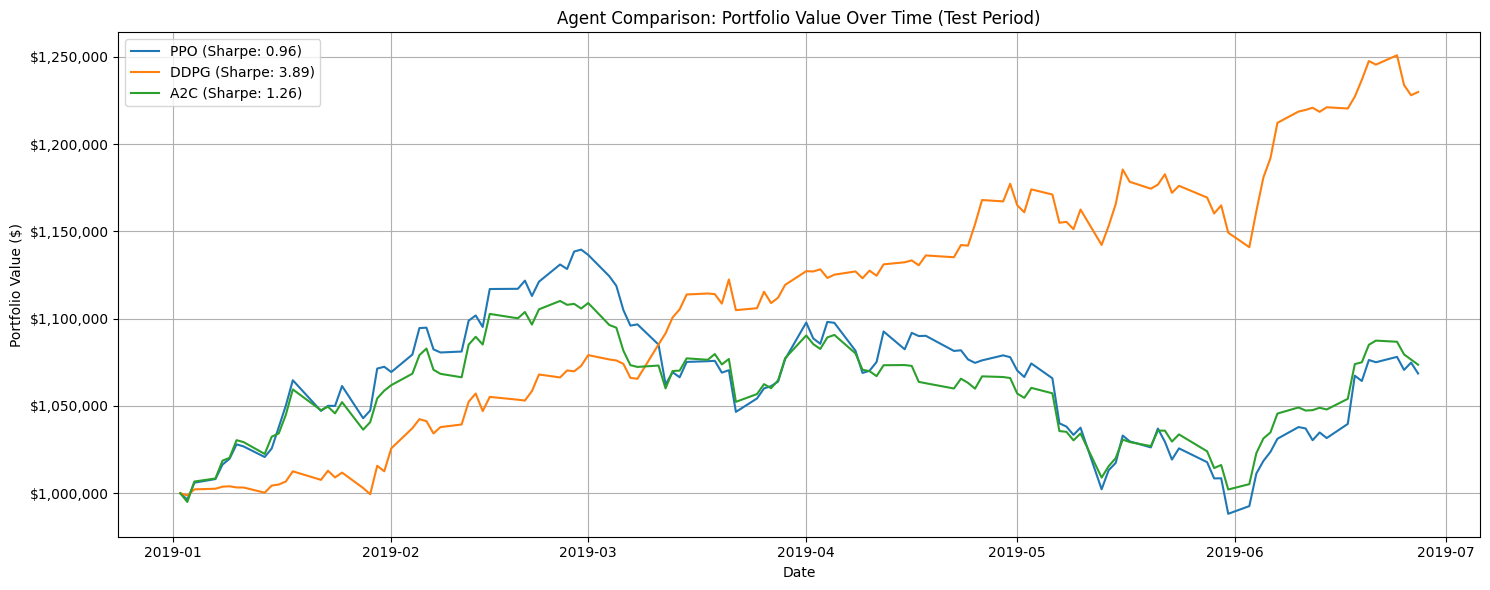

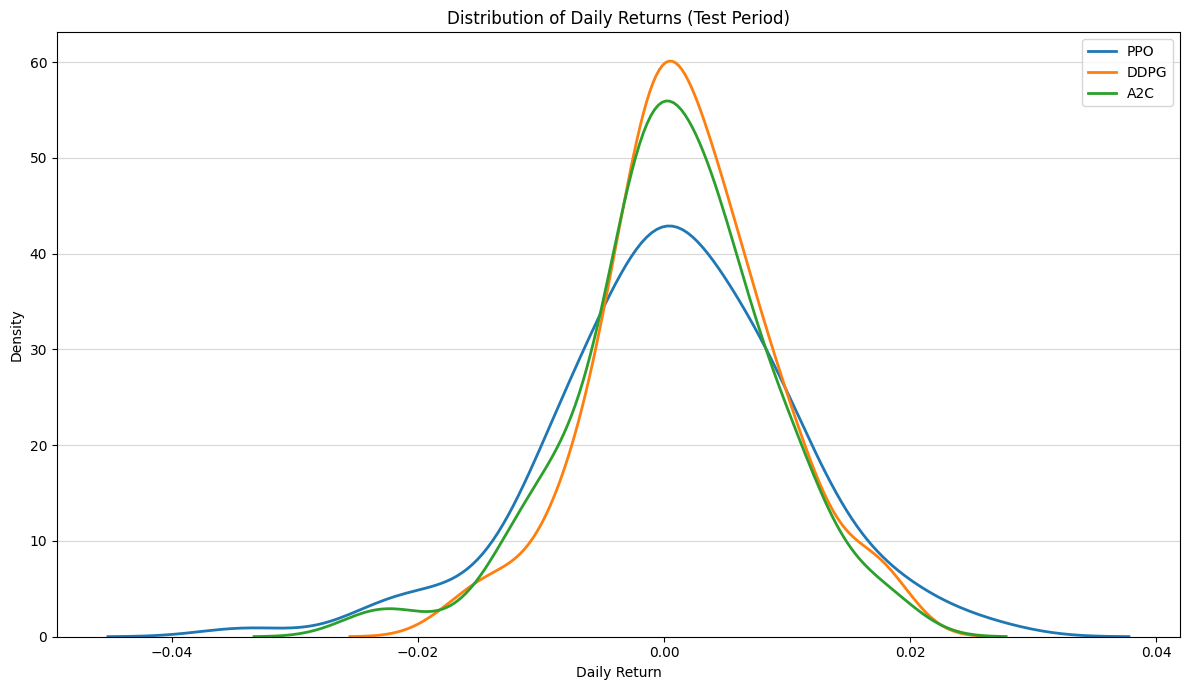

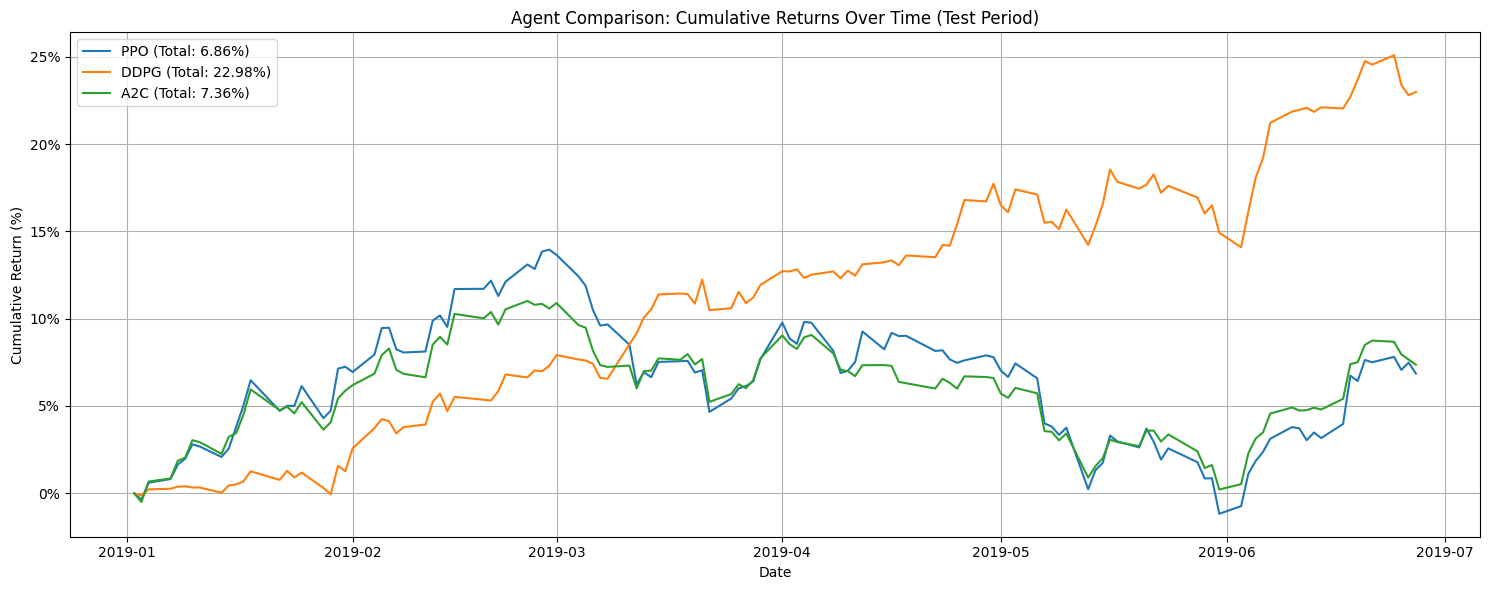

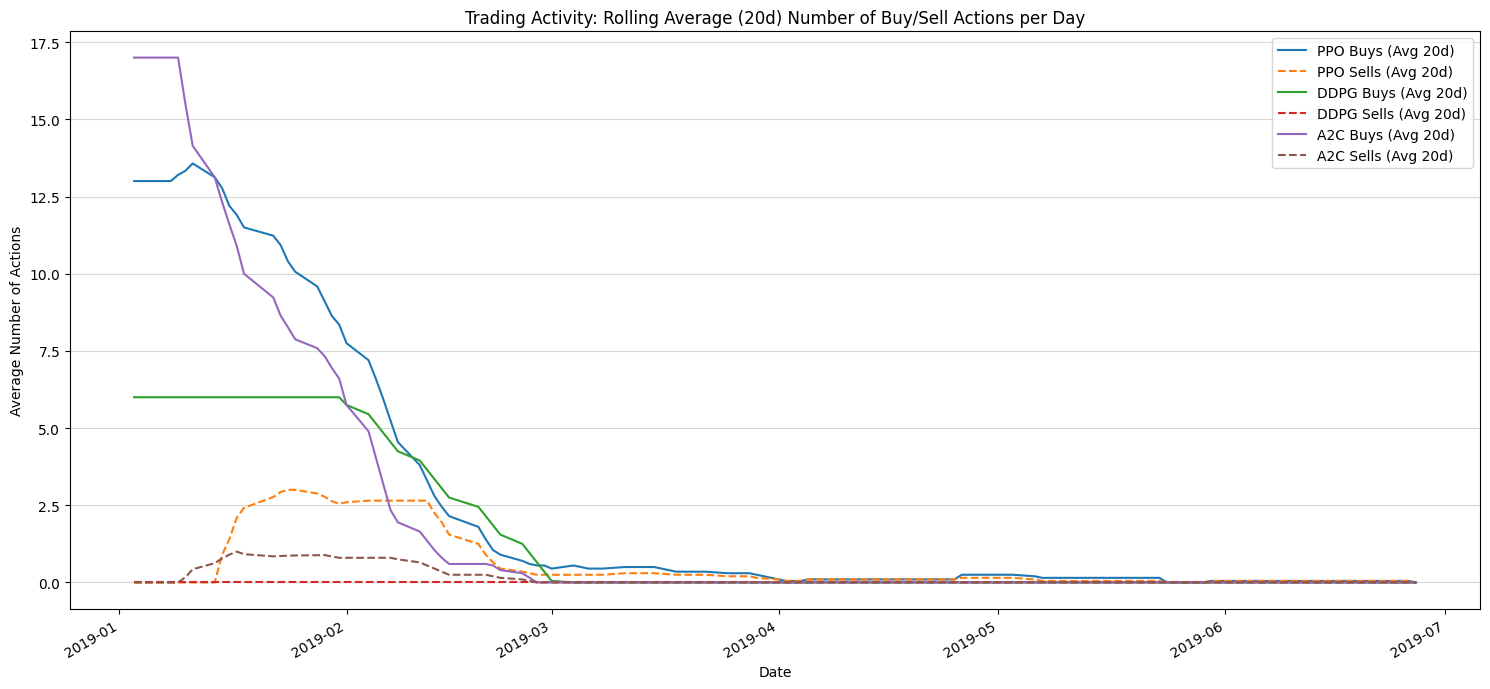

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch

%matplotlib inline


try:

    test_df = pd.read_csv("trade_with_sentiment.csv", index_col=0)

    print(f"Test data loaded successfully. Columns: {test_df.columns.tolist()}")
except FileNotFoundError:
    print("Error: test data file 'trade_with_sentiment.csv' not found.")
    test_df = None

if test_df is not None:
    stock_dim = len(test_df.tic.unique())


    tech_indicators = ['macd', 'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30',
                   'close_30_sma', 'close_60_sma', 'vix', 'turbulence', 'sentiment_2w']

    tech_indicators = [indicator for indicator in tech_indicators if indicator in test_df.columns]
    print(f"Using Technical Indicators: {tech_indicators}")


    state_space = 1 + 2*stock_dim + len(tech_indicators)*stock_dim

    action_space = stock_dim
    hmax = 100
    initial_amount = 1_000_000
    buy_cost_pct = [0.001] * stock_dim
    sell_cost_pct = [0.001] * stock_dim
    reward_scaling = 1e-4

    ppo_hidden_sizes = (64, 64)
    ddpg_hidden_sizes = (128, 128)
    a2c_hidden_sizes = (64, 64)

    device = "cuda" if torch.cuda.is_available() else "cpu"

    ppo_model_path = "./models/ppo_from_scratch.pth"
    ddpg_model_dir = "./models/ddpg_scratch_model"
    a2c_model_path = "./models/a2c_from_scratch.pth"

    print(f"Stock Dimension: {stock_dim}")
    print(f"State Space: {state_space}")


    from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

    test_env = StockTradingEnv(
        df=test_df,
        stock_dim=stock_dim,
        hmax=hmax,
        initial_amount=initial_amount,
        num_stock_shares=[0]*stock_dim,
        buy_cost_pct=buy_cost_pct,
        sell_cost_pct=sell_cost_pct,
        reward_scaling=reward_scaling,
        state_space=state_space,
        action_space=action_space,
        tech_indicator_list=tech_indicators,
        print_verbosity=1000,
        turbulence_threshold=None,
        risk_indicator_col="turbulence"
    )


    results = {}


    agent_configs = {
        "PPO": {"class": PPOAgent, "path": ppo_model_path, "hidden": ppo_hidden_sizes, "dir": False, "needs_dims": False},
        "DDPG": {"class": DDPGAgent, "path": ddpg_model_dir, "hidden": ddpg_hidden_sizes, "dir": True, "needs_dims": False},
        "A2C": {"class": A2CAgent, "path": a2c_model_path, "hidden": a2c_hidden_sizes, "dir": False, "needs_dims": False}, # Check A2C's __init__
    }

    current_state_dim = state_space
    current_action_dim = action_space

    for name, config in agent_configs.items():
        print(f"\n--- Testing {name} Agent ---")
        try:
            if config["needs_dims"]:
                 agent = config["class"](
                     state_dim=current_state_dim,
                     action_dim=current_action_dim,
                     env=test_env,
                     hidden_sizes=config["hidden"],
                     device=device
                 )
            else:
                 agent = config["class"](
                     env=test_env,
                     hidden_sizes=config["hidden"],
                     device=device
                 )

        except TypeError as e:
             print(f"TypeError during {name} instantiation: {e}")
             print(f"Please check the __init__ signature of your {name} class matches the arguments being passed.")
             continue
        except Exception as e:
            print(f"An unexpected error occurred during {name} instantiation: {e}")
            continue


        
        try:
            if config["dir"]: 
                agent.load(config["path"])
            else: 
                 agent.load(config["path"])
        except FileNotFoundError:
            print(f"Error: Model weights not found for {name} at {config['path']}")
            continue
        except Exception as e:
             print(f"An unexpected error occurred during {name} model loading: {e}")
             continue

        
        test_env.reset() 
        out = test_env.state
        state = out[0] if isinstance(out, tuple) else out
        state = np.asarray(state, dtype=np.float32) 

        done = False
        while not done:
            try:
                action = agent.predict(state) 
                step = test_env.step(action)

                if len(step) == 5:
                    obs, reward, term, trunc, info = step
                    done = bool(term or trunc)
                else:
                    obs, reward, done, info = step

                state = obs if not isinstance(obs, tuple) else obs[0]
                state = np.asarray(state, dtype=np.float32) 
            except Exception as e:
                print(f"Error during {name} rollout step: {e}")
                done = True 

        
        if test_env.day > 0:
            print(f"{name} rollout complete (or stopped due to error).")
            dates = pd.to_datetime(test_env.date_memory)
            assets = np.array(test_env.asset_memory)
            actions_df = test_env.save_action_memory()

            if len(assets) > 1:
                daily_rets = assets[1:] / assets[:-1] - 1
                total_return = assets[-1] / assets[0] - 1
                sharpe_ratio = (daily_rets.mean() / (daily_rets.std()+1e-8)) * np.sqrt(252) 

                results[name] = {
                    "dates": dates,
                    "assets": assets,
                    "actions": actions_df,
                    "daily_returns": daily_rets,
                    "total_return": total_return,
                    "sharpe_ratio": sharpe_ratio
                }
                print(f"  Test: {dates[0].date()} -> {dates[-1].date()} | "
                      f"Final=${assets[-1]:,.2f} | Return={total_return*100:.2f}% | Sharpe={sharpe_ratio:.2f}")
            else:
                 print(f"  Warning: Not enough data points in asset memory for {name} to calculate metrics.")
        else:
            print(f"  {name} rollout did not complete enough steps for analysis.")


    
    if results: 
        plt.figure(figsize=(15, 6))
        for name, data in results.items():
            plt.plot(data["dates"], data["assets"], label=f"{name} (Sharpe: {data['sharpe_ratio']:.2f})")

        plt.title("Agent Comparison: Portfolio Value Over Time (Test Period)")
        plt.xlabel("Date")
        plt.ylabel("Portfolio Value ($)")
        plt.legend()
        plt.grid(True)
        
        try:
            from matplotlib.ticker import FuncFormatter
            plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x:,.0f}"))
        except ImportError:
            print("Note: Optional currency formatting requires matplotlib.ticker")
        plt.tight_layout()
        plt.show()

       
        plt.figure(figsize=(12, 7))
        for name, data in results.items():
            sns.kdeplot(data["daily_returns"], label=f"{name}", lw=2)
           
        plt.title("Distribution of Daily Returns (Test Period)")
        plt.xlabel("Daily Return")
        plt.ylabel("Density") 
        plt.legend()
        plt.grid(True, axis='y', alpha=0.5)
        plt.tight_layout()
        plt.show()

        
        plt.figure(figsize=(15, 6))
        for name, data in results.items():
            cumulative_returns = (data["assets"] / data["assets"][0]) - 1
            plt.plot(data["dates"], cumulative_returns * 100, label=f"{name} (Total: {data['total_return']*100:.2f}%)")

        plt.title("Agent Comparison: Cumulative Returns Over Time (Test Period)")
        plt.xlabel("Date")
        plt.ylabel("Cumulative Return (%)")
        plt.legend()
        plt.grid(True)
        try:
            from matplotlib.ticker import FuncFormatter
            plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))
        except ImportError:
             print("Note: Optional percentage formatting requires matplotlib.ticker")

        plt.tight_layout()
        plt.show()


        
        plt.figure(figsize=(15, 7))
        n_agents = len(results)

        for i, (name, data) in enumerate(results.items()):
            if "actions" not in data or data["actions"].empty or \
               "dates" not in data or len(data["dates"]) < 2:
                print(f"Skipping trading activity plot for {name}: Missing or insufficient action/date data.")
                continue

            actions = data["actions"].copy() 
            buy_threshold = 0.01
            sell_threshold = -0.01

            daily_buys = (actions > buy_threshold).sum(axis=1)
            daily_sells = (actions < sell_threshold).sum(axis=1)
            if len(data["dates"]) == len(daily_buys) + 1:
                dates_for_plot = data["dates"][1:]
            elif len(data["dates"]) == len(daily_buys):
                print(f"Note: Dates and actions length match unexpectedly for {name}. Using all dates.")
                dates_for_plot = data["dates"]
            else:
                print(f"Warning: Cannot align dates (len {len(data['dates'])}) and daily actions (len {len(daily_buys)}) for {name}. Skipping activity plot.")
                continue
        
            rolling_window = 20 

            if len(daily_buys) >= rolling_window:
                
                rolling_buys_mean = daily_buys.rolling(rolling_window, min_periods=1).mean()
                rolling_sells_mean = daily_sells.rolling(rolling_window, min_periods=1).mean()

                plt.plot(dates_for_plot, rolling_buys_mean, label=f'{name} Buys (Avg {rolling_window}d)', linestyle='-')
                plt.plot(dates_for_plot, rolling_sells_mean, label=f'{name} Sells (Avg {rolling_window}d)', linestyle='--')
            elif len(daily_buys) > 0 : 
                print(f"Warning: Not enough data points ({len(daily_buys)}) for rolling window ({rolling_window}) for {name}. Plotting raw counts.")
                plt.plot(dates_for_plot, daily_buys, label=f'{name} Buys (Raw)', linestyle='-')
                plt.plot(dates_for_plot, daily_sells, label=f'{name} Sells (Raw)', linestyle='--')
            else:
                print(f"Skipping activity plot for {name}: No daily action data.")


        
        if plt.gca().has_data():
            plt.title(f"Trading Activity: Rolling Average ({rolling_window}d) Number of Buy/Sell Actions per Day")
            plt.xlabel("Date")
            plt.ylabel("Average Number of Actions")
            plt.legend(loc='best')
            plt.grid(True, axis='y', alpha=0.5)
            try:
                 plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
                 plt.gcf().autofmt_xdate() # Rotate dates
            except Exception:
                pass 
            plt.tight_layout()
            plt.show()
        else:
             plt.close()
             print("Activity plot skipped as no agents had sufficient data.")

In [ ]:
test_df.columns

Index(['date', 'tic', 'close', 'high', 'low', 'open', 'volume', 'day', 'macd',
       'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma',
       'close_60_sma', 'vix', 'turbulence', 'sentiment_2w'],
      dtype='object')

# Reinforce

In [38]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import time


class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_sizes=(64,64)):
        super().__init__()
        layers = []
        last_dim = state_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last_dim, h), nn.ReLU()]
            last_dim = h
        self.shared = nn.Sequential(*layers)
        self.mean = nn.Linear(last_dim, action_dim)
        
        self.log_std = nn.Parameter(torch.zeros(action_dim)) 

    def forward(self, x):
        x = self.shared(x)
        mean_out = self.mean(x)

       
        log_std_clamped = torch.clamp(self.log_std, -20, 2)
        std_out = torch.exp(log_std_clamped)

        
        if not torch.all(torch.isfinite(mean_out)):
            print("Warning: Non-finite values detected in policy mean output. Clamping.")
            mean_out = torch.nan_to_num(mean_out, nan=0.0, posinf=1.0, neginf=-1.0)
        if not torch.all(torch.isfinite(std_out)) or torch.any(std_out <= 0):
             print(f"Warning: Non-finite or non-positive std detected: {std_out}. Using default.")
            
             std_out = torch.ones_like(mean_out) * 0.1

        return mean_out, std_out

class REINFORCEAgent:
    def __init__(
        self,
        state_dim, 
        action_dim,
        env, 
        gamma=0.99,
        lr=1e-3, 
        hidden_sizes=(64, 64),
        log_interval=10, 
        device=None
    ):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.env = env 
        self.gamma = gamma
        self.lr = lr
        self.log_interval = log_interval
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"REINFORCE using device: {self.device}")
        print(f"  State Dim: {self.state_dim}, Action Dim: {self.action_dim}")


        if hasattr(env.action_space, 'low') and hasattr(env.action_space, 'high'):
            self.act_low = torch.tensor(env.action_space.low, dtype=torch.float32).to(self.device)
            self.act_high = torch.tensor(env.action_space.high, dtype=torch.float32).to(self.device)
            print(f"  Inferring bounds from env.action_space: {env.action_space}")
        else:
            print("Warning: env.action_space doesn't have low/high bounds. Assuming [-1, 1].")
            self.act_low = torch.full((self.action_dim,), -1.0, dtype=torch.float32).to(self.device)
            self.act_high = torch.full((self.action_dim,), 1.0, dtype=torch.float32).to(self.device)

        self.policy = PolicyNetwork(self.state_dim, self.action_dim, hidden_sizes).to(self.device)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)

        self.reset_buffer()

        self.episode_rewards = []
        self.episode_lengths = []
        self.total_steps = 0

    def reset_buffer(self):
        self.log_probs = []
        self.rewards = []

    def select_action(self, state):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device) 
        mean, std = self.policy(state_t)
        dist = Normal(mean, std)
        action = dist.sample() 

        log_prob = dist.log_prob(action).sum(dim=-1)

        self.log_probs.append(log_prob)

        action_clamped = torch.clamp(action, self.act_low, self.act_high)
        return action_clamped.squeeze(0).detach().cpu().numpy() 

    def predict(self, state):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
        with torch.no_grad():
            mean, _ = self.policy(state_t) 
        action_clamped = torch.clamp(mean, self.act_low, self.act_high)
        return action_clamped.squeeze(0).cpu().numpy()

    def update(self):
        """ Calculates loss and updates policy based on the completed episode."""
        if not self.rewards or not self.log_probs:
            print("Warning: Update called with empty rewards or log_probs buffer.")
            return None 

        T = len(self.rewards) 
        discounted_returns = np.zeros(T, dtype=np.float32)
        running_return = 0.0

        for t in reversed(range(T)):
            running_return = self.rewards[t] + self.gamma * running_return
            discounted_returns[t] = running_return

        returns = torch.tensor(discounted_returns).to(self.device)
        log_probs_t = torch.cat(self.log_probs) 

        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        
        policy_loss = -(log_probs_t * returns).mean() 

        self.optimizer.zero_grad()
        policy_loss.backward()
       
        self.optimizer.step()

        self.reset_buffer()

        return policy_loss.item()


    def learn(self, total_timesteps, verbose=False):
        """ Main REINFORCE training loop (episode-based). """

        self.total_steps = 0
        episode_count = 0
        start_time = time.time()

        while self.total_steps < total_timesteps:
            episode_count += 1
            reset_output = self.env.reset()
            state = reset_output[0] if isinstance(reset_output, tuple) else reset_output
            state = np.asarray(state, dtype=np.float32)
            self.reset_buffer() 

            episode_reward = 0
            episode_length = 0
            done = False

            while not done:
                action_np = self.select_action(state)

                step_out = self.env.step(action_np)
                if len(step_out) == 5: 
                    obs, reward, terminated, truncated, _ = step_out
                    done = bool(terminated or truncated)
                else:
                    obs, reward, done, _ = step_out

                next_state = np.asarray(obs, dtype=np.float32)
                reward = float(reward)

                self.rewards.append(reward)

                state = next_state
                episode_reward += reward
                episode_length += 1
                self.total_steps += 1

                if self.total_steps >= total_timesteps:
                     print("Total timesteps reached during episode.")
                     break 

            loss = self.update() 

            self.episode_rewards.append(episode_reward)
            self.episode_lengths.append(episode_length)

            if verbose and episode_count % self.log_interval == 0:
                avg_reward = np.mean(self.episode_rewards[-self.log_interval:])
                avg_length = np.mean(self.episode_lengths[-self.log_interval:])
                print(f"Episode: {episode_count} | Timestep: {self.total_steps}/{total_timesteps} | "
                      f"Avg Reward (Last {self.log_interval}): {avg_reward:.2f} | Avg Length: {avg_length:.1f} | "
                      f"Last Loss: {loss if loss is not None else 'N/A':.4f}")

            if self.total_steps >= total_timesteps:
                 break # Exit outer loop


        end_time = time.time()
        print("\n==========================================")
        print("Training complete.")
        print(f"Total Timesteps: {self.total_steps}")
        print(f"Total Episodes: {episode_count}")
        print(f"Training Time: {end_time - start_time:.2f} seconds")
        print("==========================================")


    def save(self, path):
        """ Saves the Policy network weights."""
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        print(f"Saving REINFORCE policy network to {path}")
        torch.save(self.policy.state_dict(), path)

    def load(self, path):
        """ Loads the Policy network weights."""
        print(f"Loading REINFORCE policy network from {path}")
        if not hasattr(self, 'policy'):
             hs = self.policy.shared[0].out_features, self.policy.shared[2].out_features 
             self.policy = PolicyNetwork(self.state_dim, self.action_dim, hs).to(self.device)

        self.policy.load_state_dict(torch.load(path, map_location=self.device))
        self.policy.eval() 
        print("REINFORCE model loaded and set to eval mode.")

In [ ]:

from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

reinforce_train_env = StockTradingEnv(
    df=train,
    stock_dim=stock_dim,
    hmax=hmax,
    initial_amount=initial_amount,
    num_stock_shares=[0]*stock_dim,
    buy_cost_pct=buy_cost_pct,
    sell_cost_pct=sell_cost_pct,
    reward_scaling=reward_scaling, 
    state_space=state_space,      
    action_space=action_space,
    tech_indicator_list=tech_indicators, 
    print_verbosity=1000,
    turbulence_threshold=None,
    risk_indicator_col="turbulence"
)
print(f"REINFORCE Training Env State Space: {reinforce_train_env.state_space}") 


reinforce_agent = REINFORCEAgent(
    state_dim=reinforce_train_env.state_space,
    action_dim=reinforce_train_env.action_space.shape[0], 
    env=reinforce_train_env, 
    gamma=0.99,
    lr=5e-4, 
    hidden_sizes=(64, 64), 
    log_interval=10, 
    device=device
)

print("Starting REINFORCE Training...")
reinforce_agent.learn(total_timesteps=100000, verbose=True) 

reinforce_agent.save("./models/reinforce_from_scratch.pth")

print("\nREINFORCE Training Finished.")
# Optional: Plot training rewards
# plt.figure(figsize=(12, 5))
# plt.plot(reinforce_agent.episode_rewards)
# plt.plot(pd.Series(reinforce_agent.episode_rewards).rolling(10).mean()) # Rolling avg
# plt.title("REINFORCE Training Episode Rewards")
# plt.xlabel("Episode")
# plt.ylabel("Total Reward")
# plt.show()

REINFORCE Training Env State Space: 378
REINFORCE using device: cpu
  State Dim: 378, Action Dim: 29
  Inferring bounds from env.action_space: Box(-1.0, 1.0, (29,), float32)
Starting REINFORCE Training...
Episode: 10 | Timestep: 7540/100000 | Avg Reward (Last 10): 55.25 | Avg Length: 754.0 | Last Loss: 0.1883
Episode: 20 | Timestep: 15080/100000 | Avg Reward (Last 10): 55.05 | Avg Length: 754.0 | Last Loss: -0.0246
Episode: 30 | Timestep: 22620/100000 | Avg Reward (Last 10): 54.05 | Avg Length: 754.0 | Last Loss: 0.0185
Episode: 40 | Timestep: 30160/100000 | Avg Reward (Last 10): 59.04 | Avg Length: 754.0 | Last Loss: 0.0950
Episode: 50 | Timestep: 37700/100000 | Avg Reward (Last 10): 71.39 | Avg Length: 754.0 | Last Loss: 0.0246
Episode: 60 | Timestep: 45240/100000 | Avg Reward (Last 10): 72.41 | Avg Length: 754.0 | Last Loss: 0.0029
Episode: 70 | Timestep: 52780/100000 | Avg Reward (Last 10): 71.48 | Avg Length: 754.0 | Last Loss: -0.1311
Episode: 80 | Timestep: 60320/100000 | Avg Re

In [39]:


agent_configs = {
    "PPO": {"class": PPOAgent, "path": ppo_model_path, "hidden": ppo_hidden_sizes, "dir": False, "needs_dims": True},
    "DDPG": {"class": DDPGAgent, "path": ddpg_model_dir, "hidden": ddpg_hidden_sizes, "dir": True, "needs_dims": False},
    "A2C": {"class": A2CAgent, "path": a2c_model_path, "hidden": a2c_hidden_sizes, "dir": False, "needs_dims": False},
    "REINFORCE": {"class": REINFORCEAgent, "path": "reinforce_from_scratch.pth", "hidden": (64, 64), "dir": False, "needs_dims": True} 
}

current_state_dim = state_space 
current_action_dim = action_space
results = {}

for name, config in agent_configs.items():
    print(f"\n--- Testing {name} Agent ---")
    try:
        if config["needs_dims"]:
             
             agent = config["class"](
                 state_dim=current_state_dim,
                 action_dim=current_action_dim,
                 env=test_env, 
                 hidden_sizes=config["hidden"],
                 device=device
             )
        else:
             agent = config["class"](
                 env=test_env,
                 hidden_sizes=config["hidden"],
                 device=device
             )
        print(f"{name} agent instantiated.")

    except TypeError as e:
         print(f"TypeError during {name} instantiation: {e}")
         continue
    except Exception as e:
        print(f"An unexpected error occurred during {name} instantiation: {e}")
        continue

    try:
        
         if config["dir"]:
             agent.load(config["path"])
         else:
             agent.load(config["path"])
         print(f"{name} model loaded successfully.")
    except Exception as e:
        
         print(f"ERROR during {name} model loading: {e}")
         continue

  


--- Testing PPO Agent ---
TypeError during PPO instantiation: PPOAgent.__init__() got an unexpected keyword argument 'state_dim'

--- Testing DDPG Agent ---
Using device: cpu
Action bounds: Low=[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.], High=[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.]
Action scale: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.], Bias: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]
DDPG agent instantiated.
Loading models from ./models/ddpg_scratch_model
DDPG model loaded successfully.

--- Testing A2C Agent ---
Using device: cpu
A2C agent instantiated.
Loading model from ./models/a2c_from_scratch.pth
A2C model loaded successfully.

--- Testing REINFORCE Agent ---
REINFORCE using device: cpu
  State Dim: 378, Action Dim: 29
  Inferring bounds from env.action_space:


--- Testing PPO Agent ---
Using device: cpu
PPO agent instantiated.
Loading model from ./models/ppo_from_scratch.pth
PPO model loaded successfully.
PPO rollout complete (or stopped due to error).
  Test: 2019-01-02 -> 2019-06-27 | Final=$1,068,575.60 | Return=6.86% | Sharpe=0.96


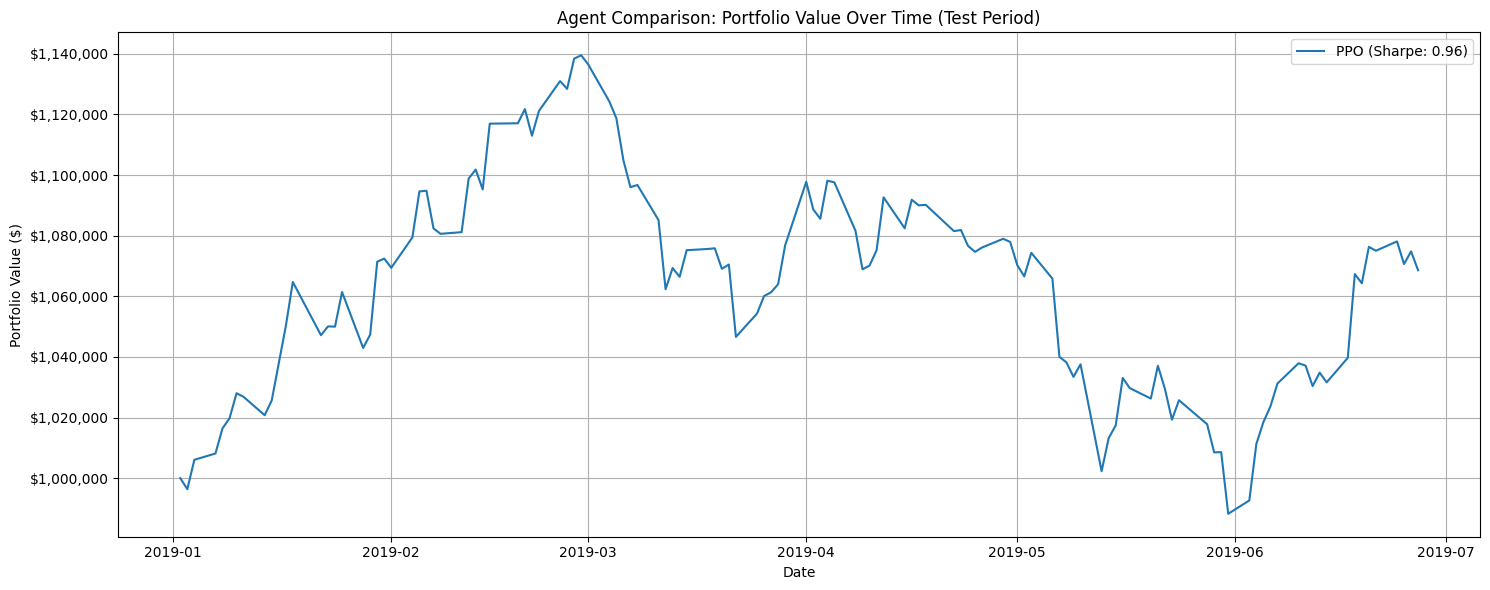

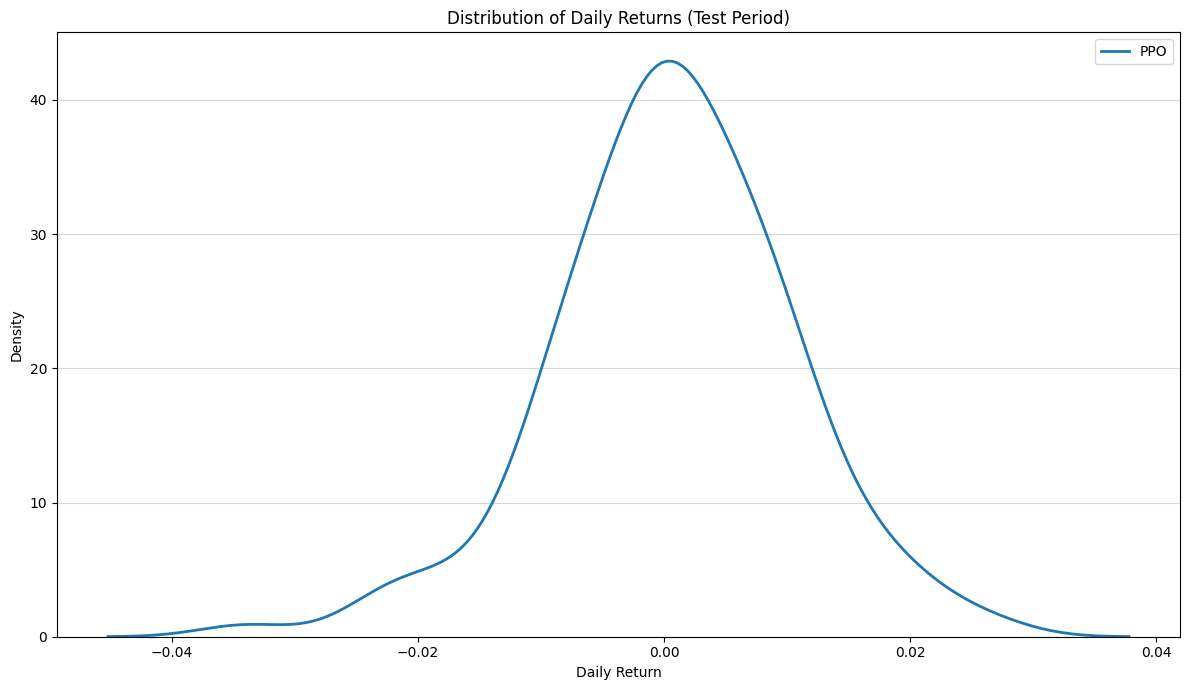

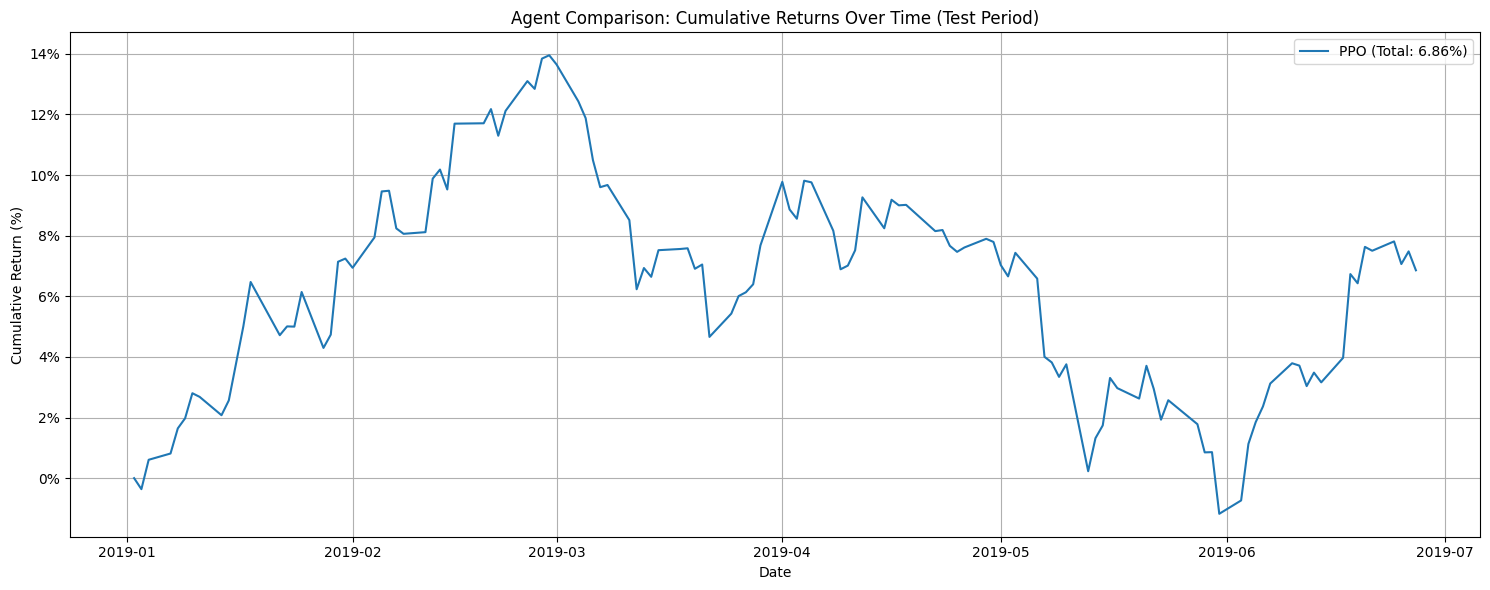

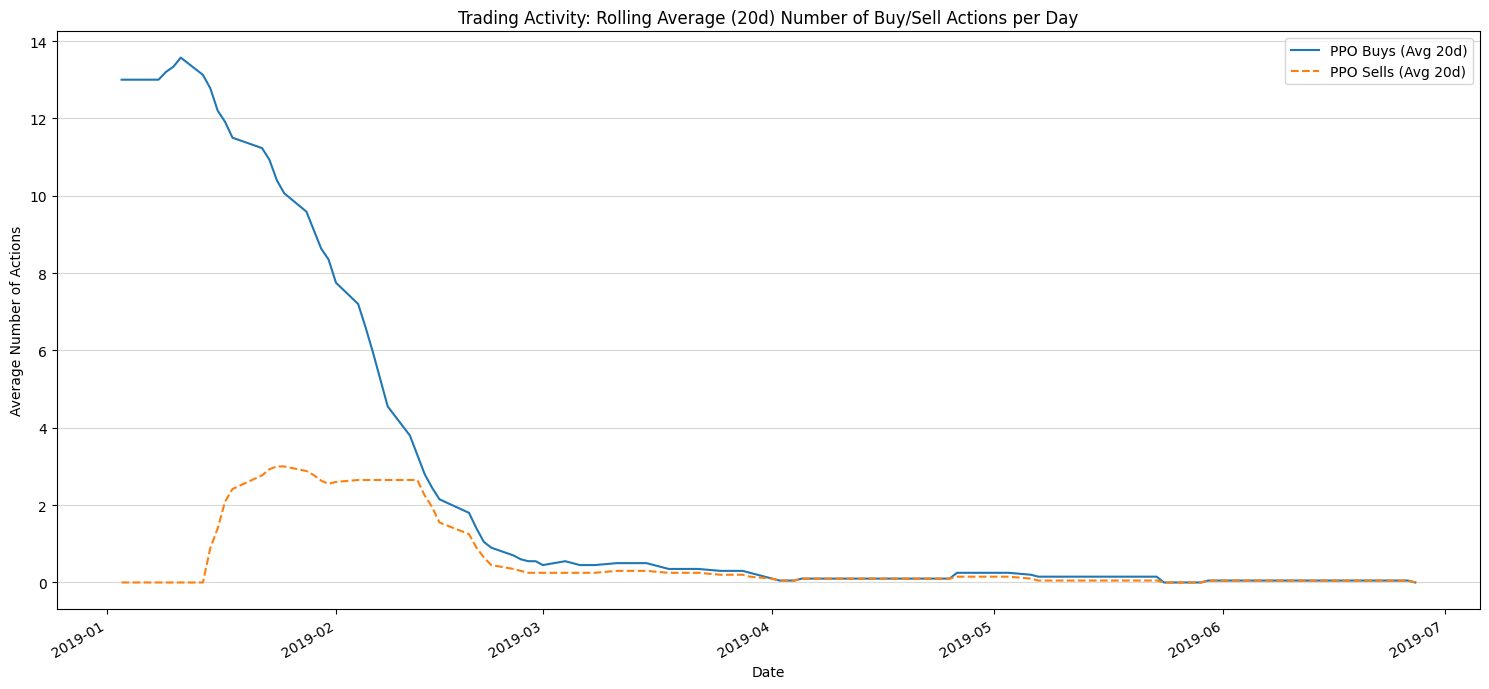


--- Testing DDPG Agent ---
Using device: cpu
Action bounds: Low=[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.], High=[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.]
Action scale: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.], Bias: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]
DDPG agent instantiated.
Loading models from ./models/ddpg_scratch_model
DDPG model loaded successfully.
DDPG rollout complete (or stopped due to error).
  Test: 2019-01-02 -> 2019-06-27 | Final=$1,229,798.22 | Return=22.98% | Sharpe=3.89


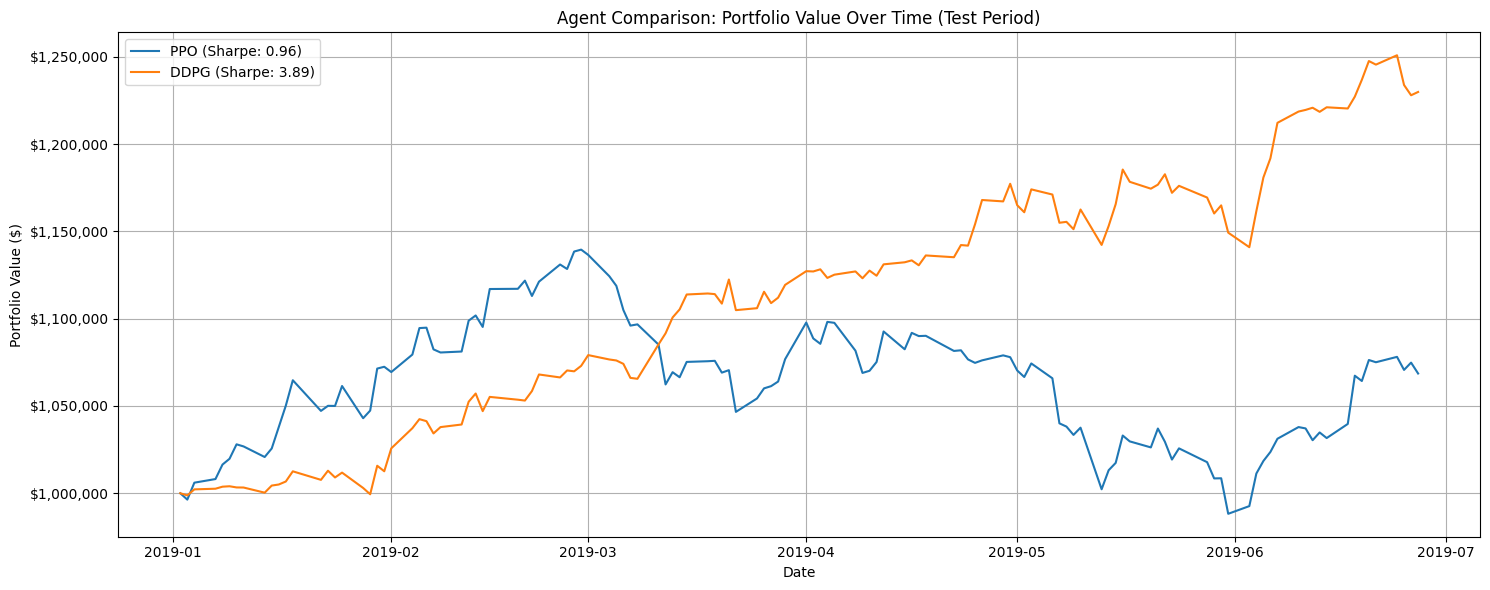

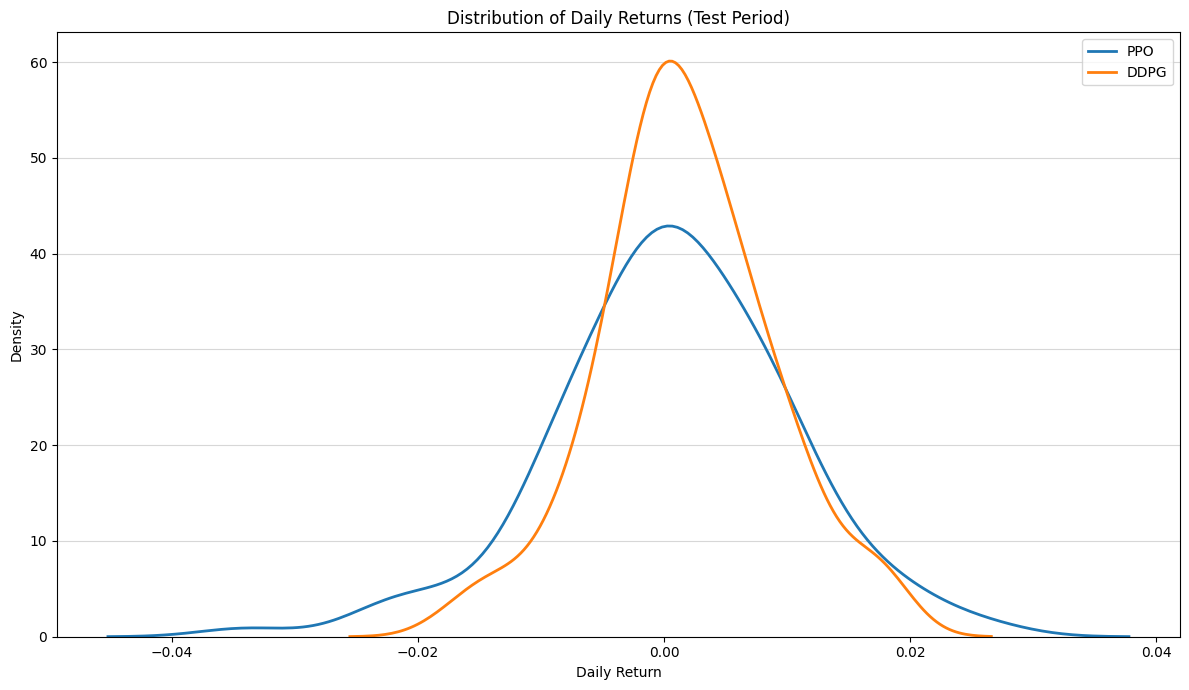

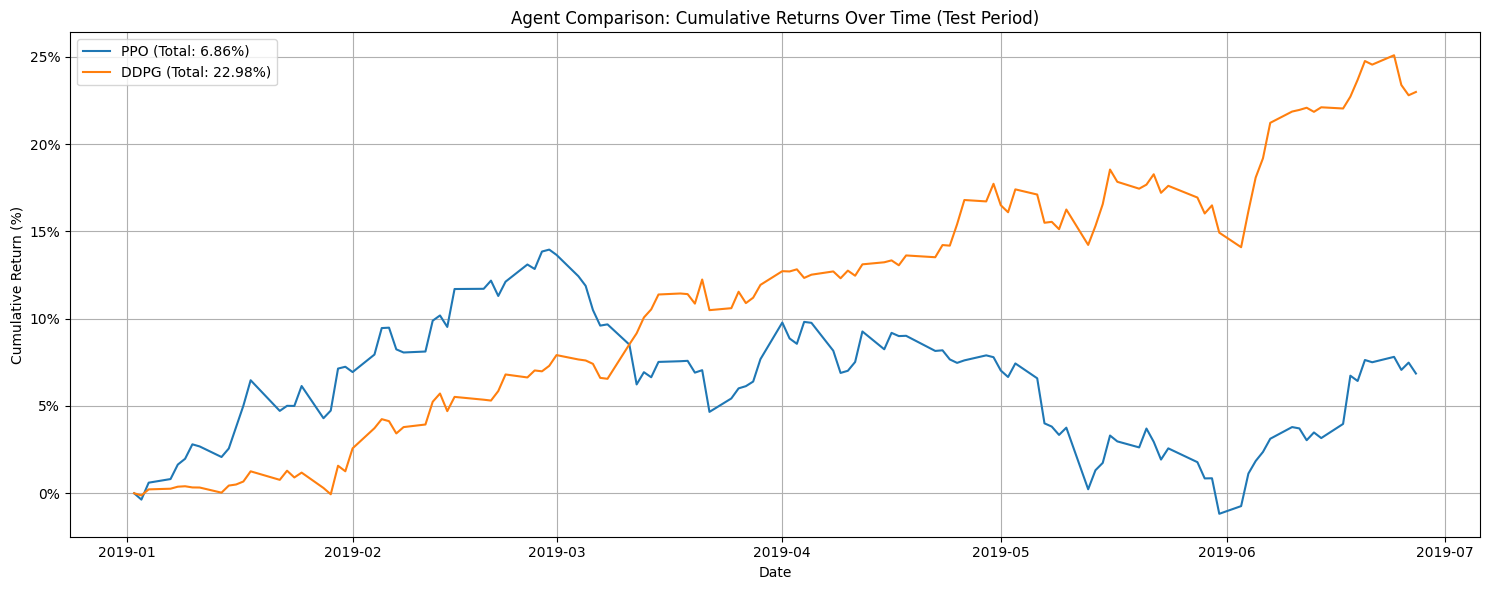

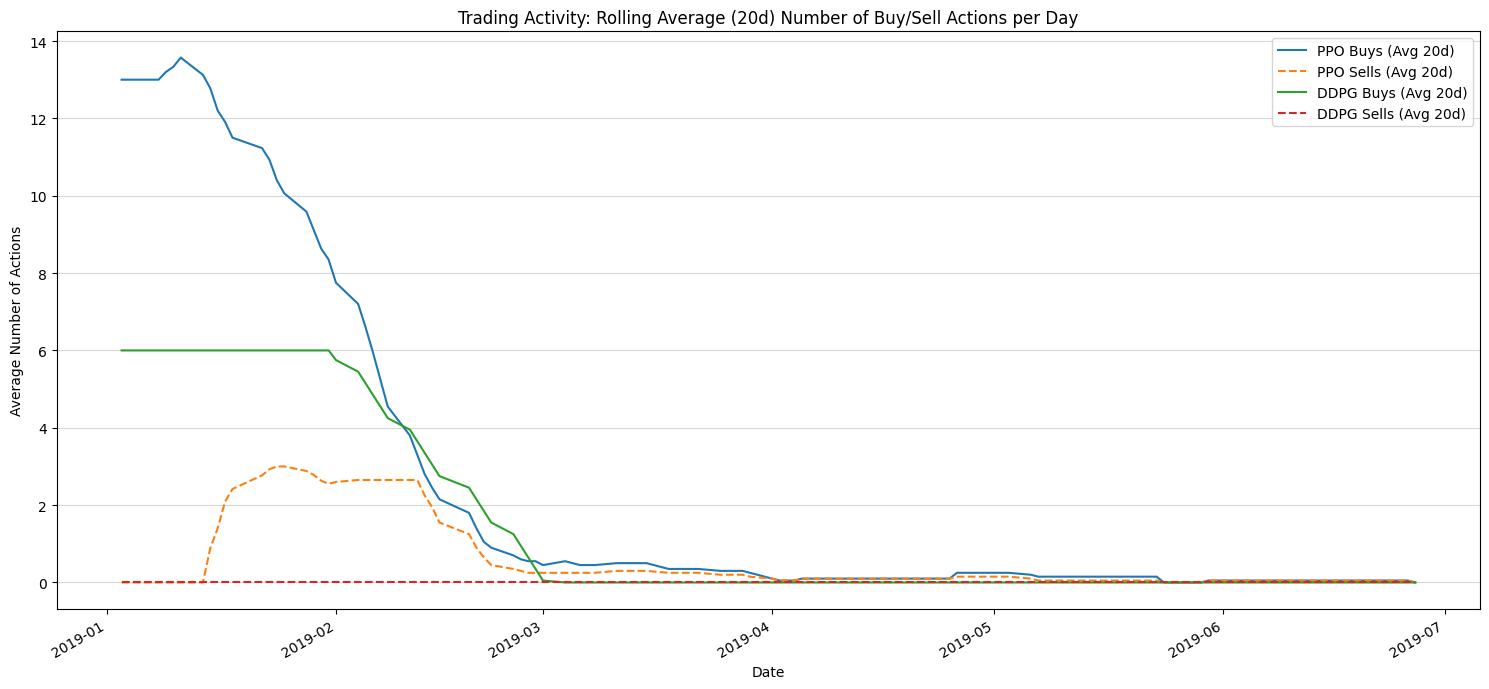


--- Testing A2C Agent ---
Using device: cpu
A2C agent instantiated.
Loading model from ./models/a2c_from_scratch.pth
A2C model loaded successfully.
A2C rollout complete (or stopped due to error).
  Test: 2019-01-02 -> 2019-06-27 | Final=$1,073,624.34 | Return=7.36% | Sharpe=1.26


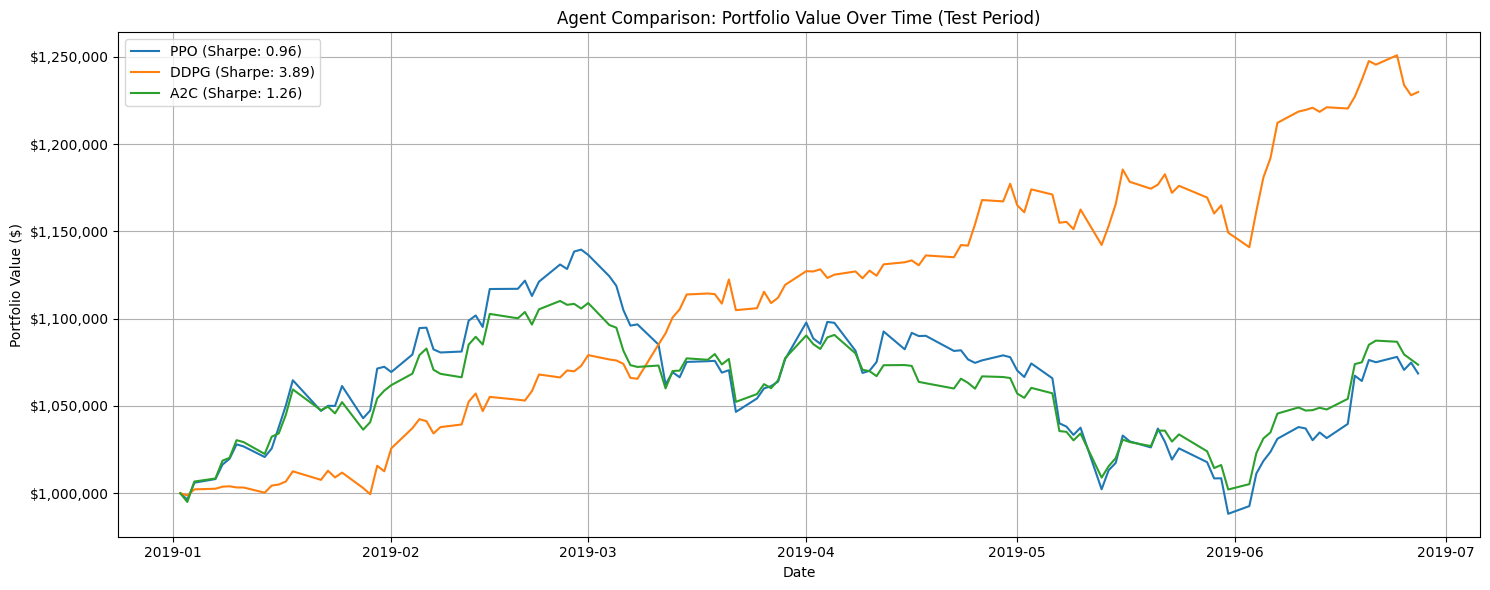

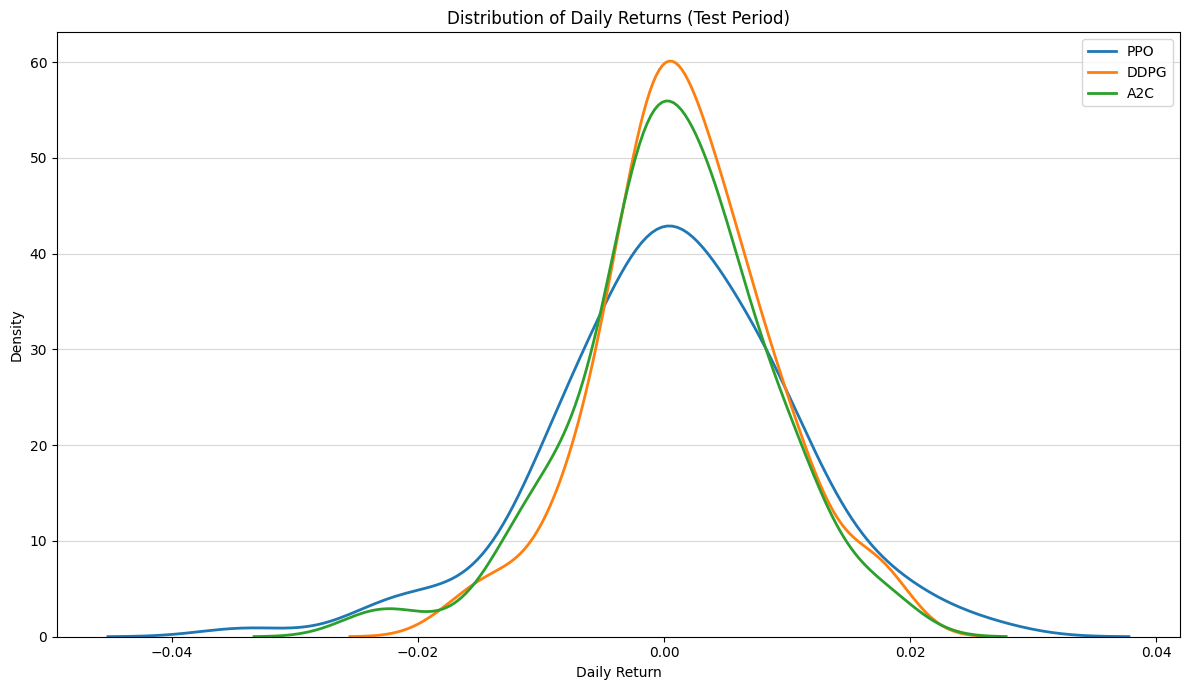

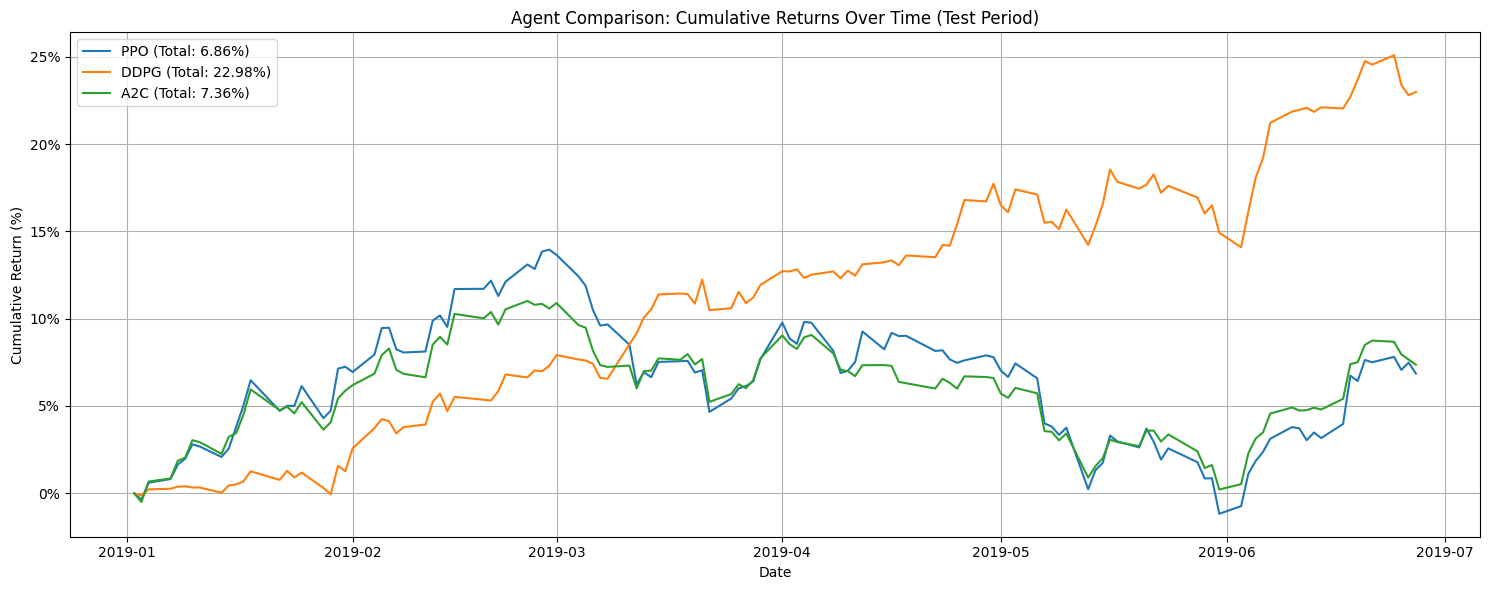

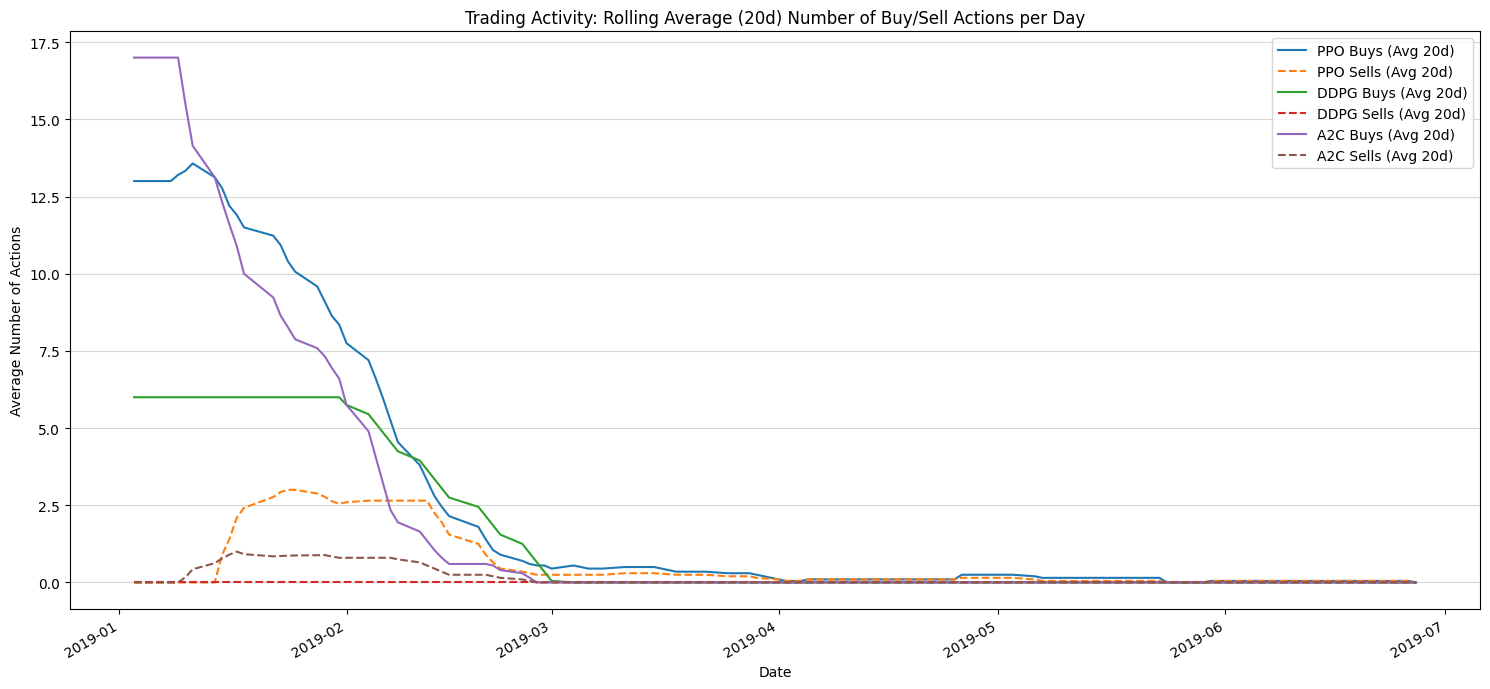


--- Testing REINFORCE Agent ---
REINFORCE using device: cpu
  State Dim: 378, Action Dim: 29
  Inferring bounds from env.action_space: Box(-1.0, 1.0, (29,), float32)
REINFORCE agent instantiated.
Loading REINFORCE policy network from ./models/reinforce_from_scratch.pth
REINFORCE model loaded and set to eval mode.
REINFORCE model loaded successfully.
REINFORCE rollout complete (or stopped due to error).
  Test: 2019-01-02 -> 2019-06-27 | Final=$1,123,982.94 | Return=12.40% | Sharpe=2.05


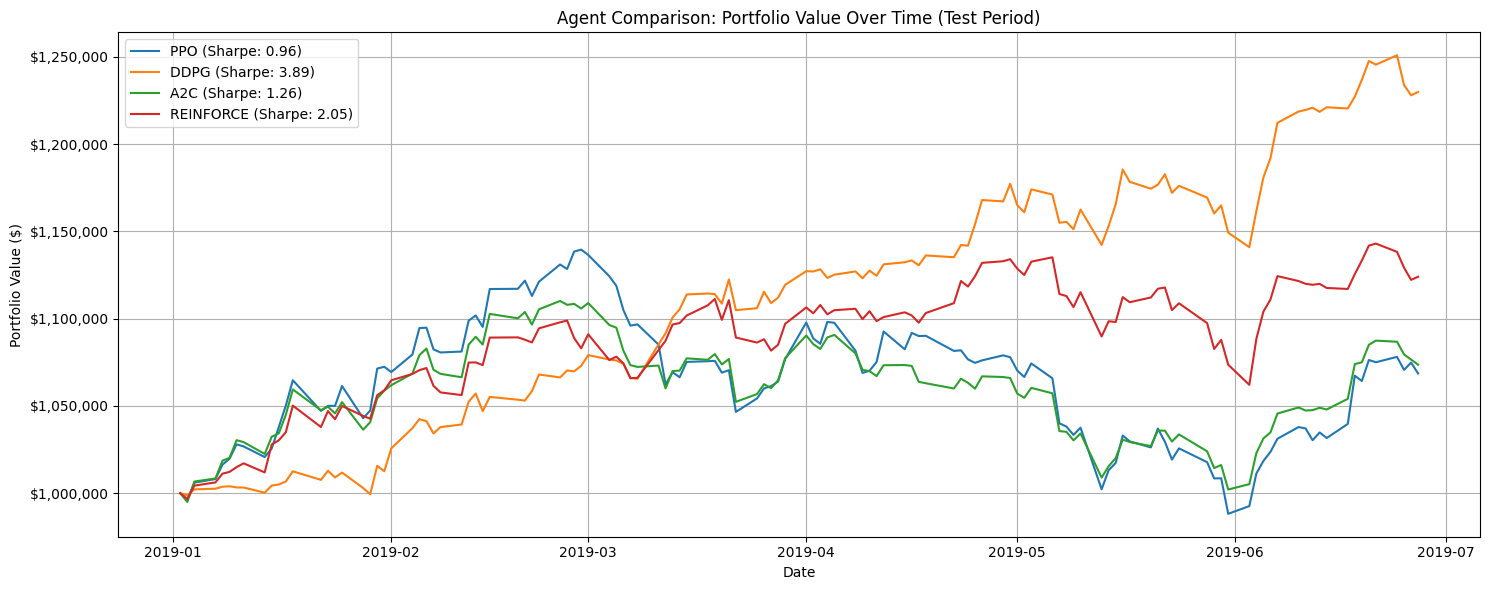

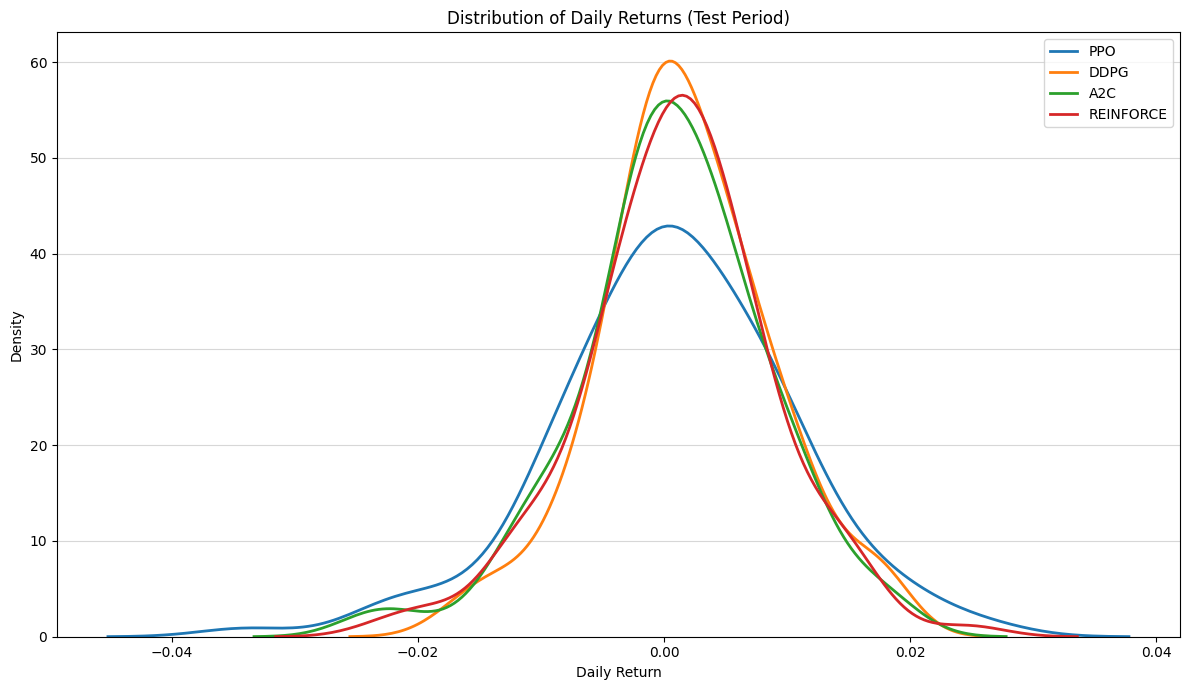

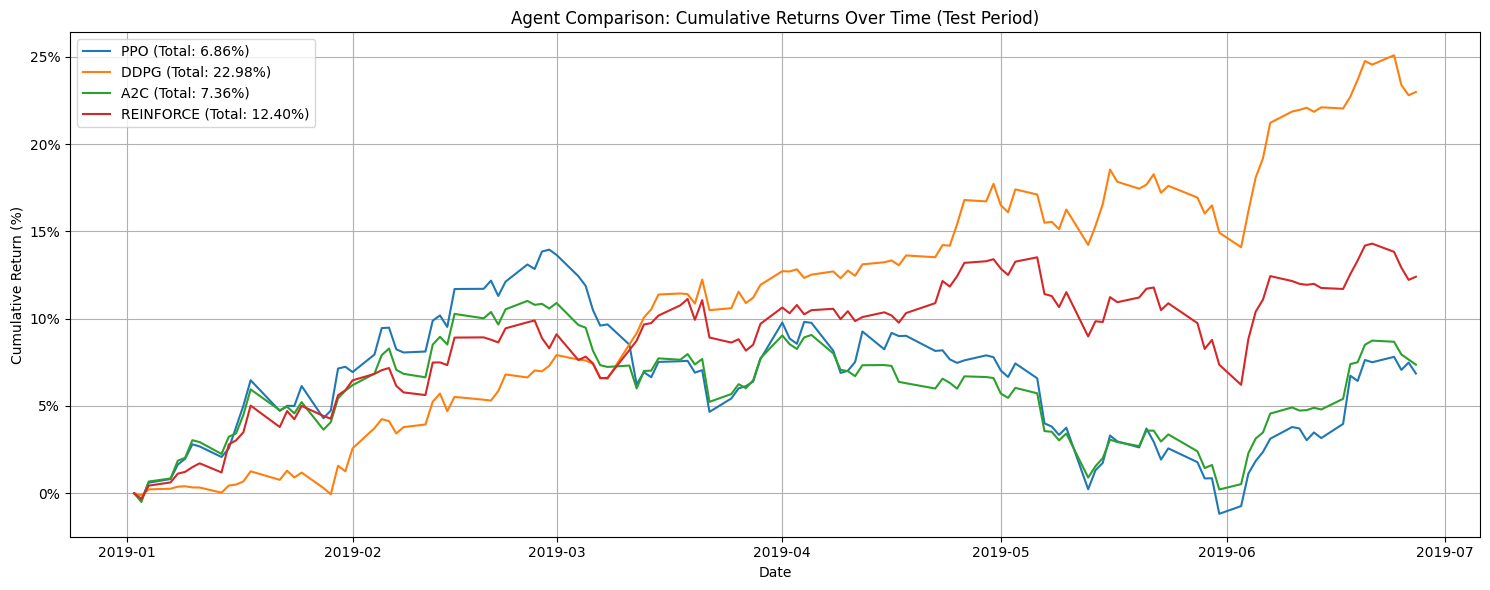

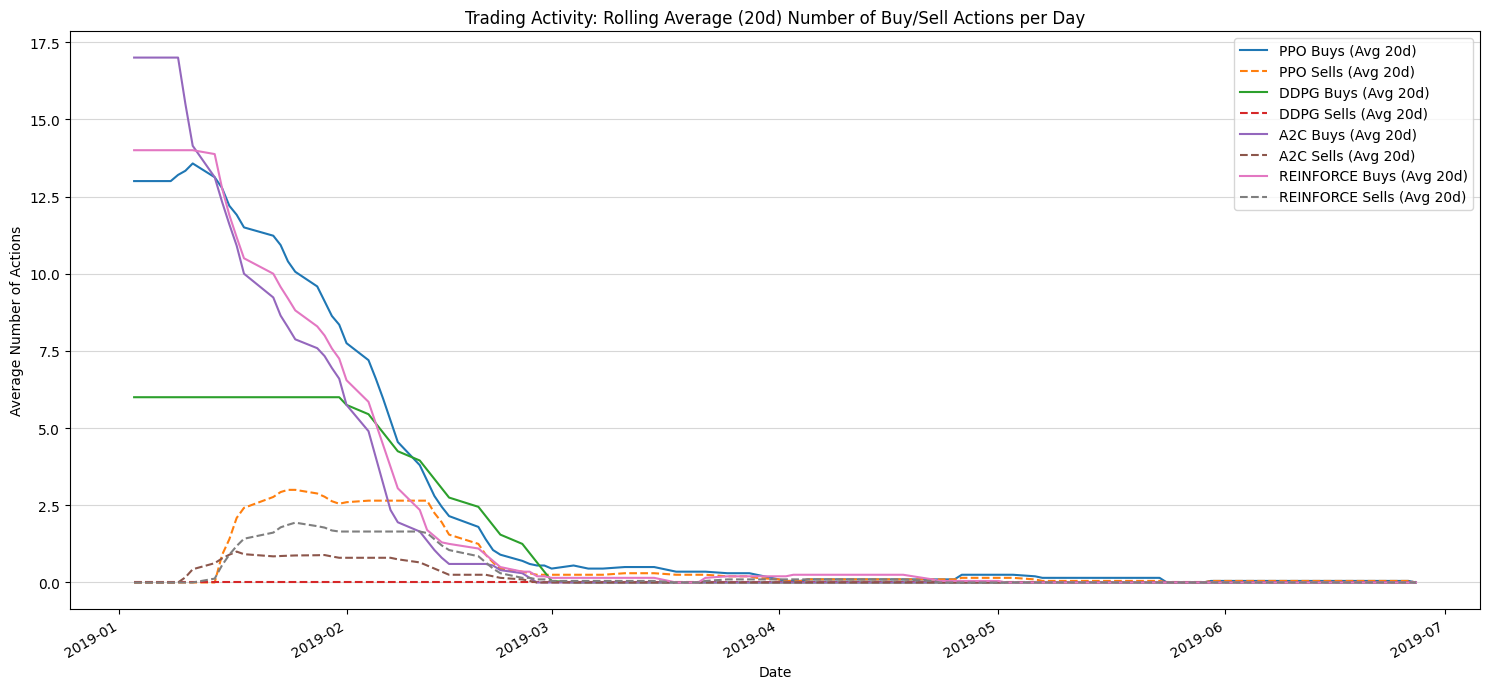

In [40]:


agent_configs = {
    "PPO": {"class": PPOAgent, "path": ppo_model_path, "hidden": ppo_hidden_sizes, "dir": False, "needs_dims": False},
    "DDPG": {"class": DDPGAgent, "path": ddpg_model_dir, "hidden": ddpg_hidden_sizes, "dir": True, "needs_dims": False},
    "A2C": {"class": A2CAgent, "path": a2c_model_path, "hidden": a2c_hidden_sizes, "dir": False, "needs_dims": False},
    "REINFORCE": {"class": REINFORCEAgent, "path": "./models/reinforce_from_scratch.pth", "hidden": (64, 64), "dir": False, "needs_dims": True} 
}

current_state_dim = state_space 
current_action_dim = action_space
results = {}

for name, config in agent_configs.items():
    print(f"\n--- Testing {name} Agent ---")
    try:
        if config["needs_dims"]:
             agent = config["class"](
                 state_dim=current_state_dim,
                 action_dim=current_action_dim,
                 env=test_env, 
                 hidden_sizes=config["hidden"],
                 device=device
             )
        else:
             agent = config["class"](
                 env=test_env,
                 hidden_sizes=config["hidden"],
                 device=device
             )
        print(f"{name} agent instantiated.")

    except TypeError as e:
         print(f"TypeError during {name} instantiation: {e}")
         continue
    except Exception as e:
        print(f"An unexpected error occurred during {name} instantiation: {e}")
        continue

    try:
         if config["dir"]:
             agent.load(config["path"])
             
         else:
             agent.load(config["path"])
         print(f"{name} model loaded successfully.")
    except Exception as e:
         print(f"ERROR during {name} model loading: {e}")
         continue

    
    test_env.reset() 
    out = test_env.state 
    state = out[0] if isinstance(out, tuple) else out
    state = np.asarray(state, dtype=np.float32) 

    done = False
    while not done:
          try:
              action = agent.predict(state) 
              step = test_env.step(action)

              if len(step) == 5:
                  obs, reward, term, trunc, info = step
                  done = bool(term or trunc)
              else:
                  obs, reward, done, info = step

              state = obs if not isinstance(obs, tuple) else obs[0]
              state = np.asarray(state, dtype=np.float32) 
          except Exception as e:
              print(f"Error during {name} rollout step: {e}")
              done = True 

        
    if test_env.day > 0:
        print(f"{name} rollout complete (or stopped due to error).")
        dates = pd.to_datetime(test_env.date_memory)
        assets = np.array(test_env.asset_memory)
        actions_df = test_env.save_action_memory() 
        if len(assets) > 1:
            daily_rets = assets[1:] / assets[:-1] - 1
            total_return = assets[-1] / assets[0] - 1
            sharpe_ratio = (daily_rets.mean() / (daily_rets.std()+1e-8)) * np.sqrt(252) 
            results[name] = {
                    "dates": dates,
                    "assets": assets,
                    "actions": actions_df,
                    "daily_returns": daily_rets,
                    "total_return": total_return,
                    "sharpe_ratio": sharpe_ratio
                }
            print(f"  Test: {dates[0].date()} -> {dates[-1].date()} | " f"Final=${assets[-1]:,.2f} | Return={total_return*100:.2f}% | Sharpe={sharpe_ratio:.2f}")
        else:
            print(f"  Warning: Not enough data points in asset memory for {name} to calculate metrics.")
    else:
          print(f"  {name} rollout did not complete enough steps for analysis.")


  

    if results: 
        plt.figure(figsize=(15, 6))
        for name, data in results.items():
            plt.plot(data["dates"], data["assets"], label=f"{name} (Sharpe: {data['sharpe_ratio']:.2f})")

        plt.title("Agent Comparison: Portfolio Value Over Time (Test Period)")
        plt.xlabel("Date")
        plt.ylabel("Portfolio Value ($)")
        plt.legend()
        plt.grid(True)
        try:
            from matplotlib.ticker import FuncFormatter
            plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x:,.0f}"))
        except ImportError:
            print("Note: Optional currency formatting requires matplotlib.ticker")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(12, 7))
        for name, data in results.items():
            sns.kdeplot(data["daily_returns"], label=f"{name}", lw=2)
            
        plt.title("Distribution of Daily Returns (Test Period)")
        plt.xlabel("Daily Return")
        plt.ylabel("Density") 
        plt.legend()
        plt.grid(True, axis='y', alpha=0.5)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(15, 6))
        for name, data in results.items():
            cumulative_returns = (data["assets"] / data["assets"][0]) - 1
            plt.plot(data["dates"], cumulative_returns * 100, label=f"{name} (Total: {data['total_return']*100:.2f}%)")

        plt.title("Agent Comparison: Cumulative Returns Over Time (Test Period)")
        plt.xlabel("Date")
        plt.ylabel("Cumulative Return (%)")
        plt.legend()
        plt.grid(True)
        try:
            from matplotlib.ticker import FuncFormatter
            plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))
        except ImportError:
             print("Note: Optional percentage formatting requires matplotlib.ticker")

        plt.tight_layout()
        plt.show()


        
        plt.figure(figsize=(15, 7))
        n_agents = len(results)

        for i, (name, data) in enumerate(results.items()):
            if "actions" not in data or data["actions"].empty or \
               "dates" not in data or len(data["dates"]) < 2:
                print(f"Skipping trading activity plot for {name}: Missing or insufficient action/date data.")
                continue

            actions = data["actions"].copy()
            buy_threshold = 0.01
            sell_threshold = -0.01

            daily_buys = (actions > buy_threshold).sum(axis=1)
            daily_sells = (actions < sell_threshold).sum(axis=1)
            
            if len(data["dates"]) == len(daily_buys) + 1:
                dates_for_plot = data["dates"][1:] 
            elif len(data["dates"]) == len(daily_buys):
                print(f"Note: Dates and actions length match unexpectedly for {name}. Using all dates.")
                dates_for_plot = data["dates"]
            else:
                print(f"Warning: Cannot align dates (len {len(data['dates'])}) and daily actions (len {len(daily_buys)}) for {name}. Skipping activity plot.")
                continue
            
            rolling_window = 20 

            if len(daily_buys) >= rolling_window:
                
                rolling_buys_mean = daily_buys.rolling(rolling_window, min_periods=1).mean()
                rolling_sells_mean = daily_sells.rolling(rolling_window, min_periods=1).mean()

                plt.plot(dates_for_plot, rolling_buys_mean, label=f'{name} Buys (Avg {rolling_window}d)', linestyle='-')
                plt.plot(dates_for_plot, rolling_sells_mean, label=f'{name} Sells (Avg {rolling_window}d)', linestyle='--')
            elif len(daily_buys) > 0 : 
                print(f"Warning: Not enough data points ({len(daily_buys)}) for rolling window ({rolling_window}) for {name}. Plotting raw counts.")
                plt.plot(dates_for_plot, daily_buys, label=f'{name} Buys (Raw)', linestyle='-')
                plt.plot(dates_for_plot, daily_sells, label=f'{name} Sells (Raw)', linestyle='--')
            else:
                print(f"Skipping activity plot for {name}: No daily action data.")


        
        if plt.gca().has_data():
            plt.title(f"Trading Activity: Rolling Average ({rolling_window}d) Number of Buy/Sell Actions per Day")
            plt.xlabel("Date")
            plt.ylabel("Average Number of Actions")
            plt.legend(loc='best') 
            plt.grid(True, axis='y', alpha=0.5)
            try:
                 plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
                 plt.gcf().autofmt_xdate() 
            except Exception:
                pass 
            plt.tight_layout()
            plt.show()
        else:
             plt.close() 
             print("Activity plot skipped as no agents had sufficient data.")
   

# Test against market returns

In [76]:
df_dji = pd.read_csv("./dji30.csv")

In [77]:
df_dji = df_dji[['date','close']]
fst_day = df_dji['close'][0]
dji = pd.merge(df_dji['date'], df_dji['close'].div(fst_day).mul(1000000), 
               how='outer', left_index=True, right_index=True).set_index('date')
# dji

In [78]:
dji.columns

Index(['close'], dtype='object')

In [82]:
dji = dji.reset_index()

In [83]:
dji['date'] = pd.to_datetime(dji['date'])
mask = (dji['date'] > TRADE_START_DATE) & (dji['date'] < TRADE_END_DATE)
dji = dji.loc[mask]

In [84]:
dji

,date,close
0,2019-01-02,1.000000e+06
1,2019-01-03,9.719589e+05
2,2019-01-04,1.003749e+06
3,2019-01-07,1.008166e+06
4,2019-01-08,1.019087e+06
...,...,...
99,2019-05-31,1.063164e+06
100,2019-06-03,1.063370e+06
101,2019-06-04,1.085323e+06
102,2019-06-05,1.094209e+06


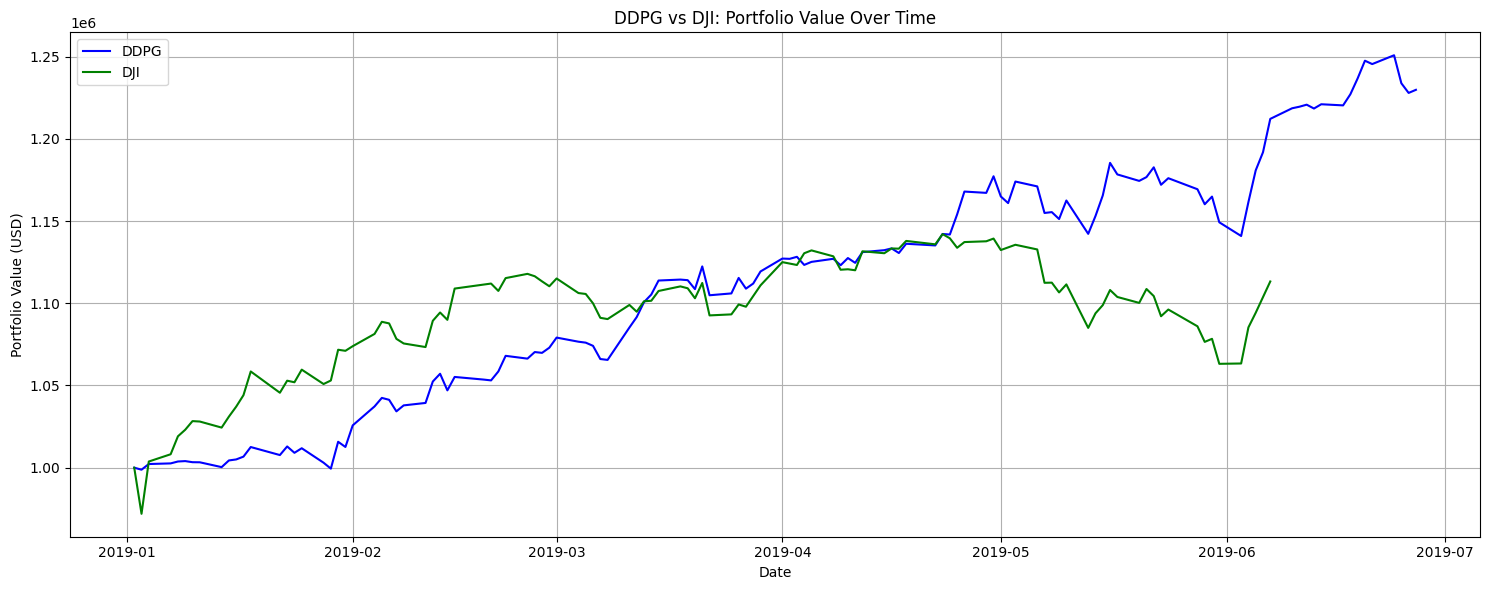

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
# DDPG
ddpg_dates  = results['DDPG']['dates']
ddpg_assets = results['DDPG']['assets']
plt.plot(ddpg_dates, ddpg_assets, color='blue', label='DDPG')

# DJI
dji['date'] = pd.to_datetime(dji['date'])
plt.plot(dji['date'], dji['close'], color='green', label='DJI')

plt.title("DDPG vs DJI: Portfolio Value Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Couldn't able to fetch data from 7th July 2019 for DJI hence couldn't plot further!!!

In [ ]:
# Github Logs -> https://github.com/MananJain2002/RL_Final_Project

In [ ]:
# Github Project